# 12 — Final Agent Demo and Report Outputs

## 这是技术开发的最后一个 Notebook

这一 Notebook **不再训练模型、不再调整检索规则、不读取 Test 的逐行真实标签，也不调用任何付费 API**。它只把已经冻结的两部分组合成一个可以演示的学生项目：

1. **预测层**：读取冻结模型已经生成的支持概率；
2. **解释层**：解释概率由哪两个部分组成，以及哪些模型因素提高或降低了概率；
3. **RAG 材料层**：展示 Direct、Related policy、Similar votes 和 Legislative background；
4. **报告层**：导出最终表格、案例和图片，供报告与演示使用。

产品流程可以通俗地理解为：

```text
选择一条议案和一个政党
        ↓
读取已经冻结的支持概率
        ↓
解释模型计算过程
        ↓
展示检索到的政策资料
        ↓
明确说明资料是否足够，以及它不能改变预测
```

这里不会让 RAG 再投一次票。RAG 找到的材料是解释和延伸阅读，不是真实答案，也不会覆盖模型概率。

## 证据层级怎样理解

| Evidence tier | 通俗含义 | 可以做什么 | 不可以做什么 |
|---|---|---|---|
| Direct | 找到程序、政策对象和政治角色都较接近的历史投票 | 作为最接近的历史参照 | 不能证明本次一定同样投票 |
| Related policy | 竞选纲领或其他与主题相关的政策材料 | 说明政党的政策背景 | 不能直接推断支持或反对 |
| Similar votes | 主题相似但并非同一政策对象的历史投票 | 给用户推荐相似案例 | 不能当成当前议案的方向证据 |
| Legislative background | Bill 名称、阶段和摘要 | 帮助理解立法背景 | 不能代表政党立场 |

如果没有可靠材料，产品会诚实显示“没有找到可靠的外部资料”。这不是程序失败，而是避免为了给出解释而拼凑不相关证据。

In [64]:
# 导入本地数据整理与绘图工具；本 Notebook 不导入 OpenAI SDK
import json
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid")

# 使用绝对路径，避免从不同工作目录启动 Notebook 时找不到文件
PROJECT_DIR = Path.cwd()
PROCESSED_DIR = PROJECT_DIR / "processed"
PREDICTION_DIR = PROCESSED_DIR / "final_test_three_role_v1"
EVIDENCE_DIR = PROCESSED_DIR / "evidence_precision_v5"
FREEZE_DIR = PROCESSED_DIR / "three_role_scope_freeze_v1"
OUTPUT_DIR = PROCESSED_DIR / "final_agent_demo_v1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREDICTIONS_PATH = PREDICTION_DIR / "final_test_predictions_public_v1.csv"
MODEL_METRICS_PATH = PREDICTION_DIR / "final_test_model_metrics_v1.csv"
PARTY_METRICS_PATH = PREDICTION_DIR / "final_test_party_metrics_v1.csv"
YEAR_METRICS_PATH = PREDICTION_DIR / "final_test_year_metrics_v1.csv"
PACKETS_PATH = EVIDENCE_DIR / "agent_evidence_packets_v5.csv"
EVIDENCE_PATH = EVIDENCE_DIR / "evidence_tiers_v5.csv"
STATUS_PATH = EVIDENCE_DIR / "query_evidence_status_v5.csv"
FREEZE_MANIFEST_PATH = FREEZE_DIR / "three_role_model_freeze_manifest_v1.json"

EXPECTED_FREEZE_SHA256 = "175a2caaa62756fc0a47545afed76f2b07d233409cee20bafcfeb14d6bddd2fc"
PRIMARY_MODEL = "role_prior_blend_50_50"
IN_SCOPE_PARTIES = ["labour", "conservative", "liberal-democrat"]

## 1. 读取冻结产物

这里直接读取第 10 步生成的公开预测，而不是重新拟合模型。这样可以保证最终演示仍然使用已经冻结并完成一次性 Test 的同一个模型。

读取的指标表只是已经汇总好的报告结果。本 Notebook 不读取包含 `target` 的逐行私有测试文件。

In [65]:
# 先检查全部输入是否存在，缺少文件时一次性给出清晰提示
required_paths = [
    PREDICTIONS_PATH,
    MODEL_METRICS_PATH,
    PARTY_METRICS_PATH,
    YEAR_METRICS_PATH,
    PACKETS_PATH,
    EVIDENCE_PATH,
    STATUS_PATH,
    FREEZE_MANIFEST_PATH,
]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("缺少以下输入文件：\n" + "\n".join(missing_paths))

predictions = pd.read_csv(PREDICTIONS_PATH, parse_dates=["motion_date"])
model_metrics = pd.read_csv(MODEL_METRICS_PATH)
party_metrics = pd.read_csv(PARTY_METRICS_PATH)
year_metrics = pd.read_csv(YEAR_METRICS_PATH)
packets = pd.read_csv(PACKETS_PATH, parse_dates=["motion_date"])
evidence = pd.read_csv(EVIDENCE_PATH, parse_dates=["query_date", "evidence_date"])
status = pd.read_csv(STATUS_PATH, parse_dates=["motion_date"])

with FREEZE_MANIFEST_PATH.open("r", encoding="utf-8") as handle:
    freeze_manifest = json.load(handle)

print("Public predictions:", len(predictions))
print("Unique divisions:", predictions["division_key"].nunique())
print("Evidence rows:", len(evidence))
print("Evidence packets:", len(packets))
print("Frozen model:", freeze_manifest["primary_model"])

Public predictions: 975
Unique divisions: 354
Evidence rows: 331
Evidence packets: 975
Frozen model: role_prior_blend_50_50


## 2. 免费结构检查

这些检查不是在评价模型表现，而是在确认最终产品没有接错文件：

- 每个 `row_id` 只能对应一个“议案 × 政党”预测；
- 三个产品范围内政党必须完整；
- 冻结模型的 SHA-256 必须与第 9C、10 步一致；
- 公开输入中不能出现逐行 Test 真实标签；
- RAG 的概率和预测覆盖开关必须全部为 `False`。

In [66]:
# 将字符串形式的 True/False 稳定转换成布尔值
def as_bool(series):
    # 把常见布尔表示转换成真正的布尔类型
    return series.astype(str).str.strip().str.lower().map({"true": True, "false": False})


# 逐行真实标签通常含 target、actual 或 label 字样；历史证据的 stance_label 不属于当前 Test 标签
forbidden_prediction_columns = [
    column for column in predictions.columns
    if column.startswith("target_") or column in {"actual", "actual_stance", "true_label"}
]

structural_gates = {
    "prediction_row_id_unique_gate": bool(predictions["row_id"].is_unique),
    "packet_row_id_unique_gate": bool(packets["row_id"].is_unique),
    "all_predictions_have_packet_gate": bool(set(predictions["row_id"]) <= set(packets["row_id"])),
    "three_parties_only_gate": bool(set(predictions["party"]) == set(IN_SCOPE_PARTIES)),
    "primary_model_gate": bool(set(predictions["prediction_model"]) == {PRIMARY_MODEL}),
    "freeze_hash_gate": bool(
        freeze_manifest["freeze_sha256"] == EXPECTED_FREEZE_SHA256
        and set(predictions["freeze_sha256"]) == {EXPECTED_FREEZE_SHA256}
    ),
    "no_row_level_test_label_gate": bool(len(forbidden_prediction_columns) == 0),
    "rag_does_not_change_probability_gate": bool(
        (~as_bool(packets["rag_changes_probability_v5"]).fillna(False)).all()
    ),
    "rag_not_second_predictor_gate": bool(
        (~as_bool(packets["rag_produces_separate_prediction_v5"]).fillna(False)).all()
    ),
    "prediction_not_overridden_gate": bool(
        (~as_bool(packets["prediction_overridden_v5"]).fillna(False)).all()
    ),
}

display(pd.Series(structural_gates, name="passed").to_frame())
if not all(structural_gates.values()):
    failed = [name for name, passed in structural_gates.items() if not passed]
    raise ValueError("最终整合结构检查失败：" + ", ".join(failed))

,passed
prediction_row_id_unique_gate,True
packet_row_id_unique_gate,True
all_predictions_have_packet_gate,True
three_parties_only_gate,True
primary_model_gate,True
freeze_hash_gate,True
no_row_level_test_label_gate,True
rag_does_not_change_probability_gate,True
rag_not_second_predictor_gate,True
prediction_not_overridden_gate,True


## 3. 合并预测解释和 RAG 状态

最终支持概率的公式已经在第 10 步固定：

```text
支持概率 = 50% × Role-only XGBoost 概率
         + 50% × 该政党最近 100 次投票的支持比例
```

第一部分根据议案程序、议会角色、政府背书等结构化特征判断；第二部分让模型跟上政党近期行为。RAG 资料不参与这条公式。

In [67]:
# 只从证据包选择最终展示所需字段，避免重复合并预测列
packet_columns = [
    "row_id",
    "query_id",
    "effective_policy_object",
    "policy_object_source",
    "query_confidence",
    "query_review_required",
    "probability_formula",
    "top_supporting_model_drivers",
    "top_opposing_model_drivers",
    "recent_prior_window",
    "recent_prior_support_votes_estimated",
    "recent_prior_oppose_votes_estimated",
    "product_evidence_status_v5",
    "product_evidence_message_v5",
    "direct_evidence_ids_v5",
    "related_policy_ids_v5",
    "similar_vote_ids_v5",
    "legislative_background_ids_v5",
    "all_evidence_ids_v5",
]

product = predictions.merge(
    packets[packet_columns],
    on="row_id",
    how="left",
    validate="one_to_one",
)

if product["query_id"].isna().any():
    raise ValueError("部分预测没有对应的 RAG 证据包。")

# 该分档只描述概率距离 0.5 有多远，不等于统计学置信区间
probability_distance = (product["support_probability"] - 0.5).abs()
product["probability_distance_band"] = np.select(
    [probability_distance >= 0.25, probability_distance >= 0.10],
    ["far_from_0.5", "moderately_away_from_0.5"],
    default="close_to_0.5",
)

product["policy_object_for_display"] = product["effective_policy_object"].fillna("").str.strip()
empty_object = product["policy_object_for_display"].eq("")
product.loc[empty_object, "policy_object_for_display"] = product.loc[empty_object, "motion_title_clean"]

display(product[[
    "row_id", "motion_date", "party", "party_role", "motion_title_clean",
    "predicted_stance", "support_probability", "probability_distance_band",
    "product_evidence_status_v5",
]].head(8))

,row_id,motion_date,party,party_role,motion_title_clean,predicted_stance,support_probability,probability_distance_band,product_evidence_status_v5
0,pw-2025-01-14-75-commons__conservative,2025-01-14,conservative,main_opposition,Renters — Rights Bill: New Clause 13 - Prohibition of rent in advance after lease entered into (except initial rent),support,0.564635,close_to_0.5,no_external_material
1,pw-2025-01-14-75-commons__labour,2025-01-14,labour,governing_party,Renters — Rights Bill: New Clause 13 - Prohibition of rent in advance after lease entered into (except initial rent),oppose,0.439855,close_to_0.5,no_external_material
2,pw-2025-01-14-76-commons__conservative,2025-01-14,conservative,main_opposition,New Clause 20: Renters — Rights Bill,support,0.527944,close_to_0.5,no_external_material
3,pw-2025-01-14-76-commons__labour,2025-01-14,labour,governing_party,New Clause 20: Renters — Rights Bill,oppose,0.415541,close_to_0.5,no_external_material
4,pw-2025-01-14-76-commons__liberal-democrat,2025-01-14,liberal-democrat,smaller_opposition,New Clause 20: Renters — Rights Bill,support,0.819389,far_from_0.5,no_external_material
5,pw-2025-01-14-77-commons__conservative,2025-01-14,conservative,main_opposition,Clause 1 - Assured tenancies to be periodic with rent period not exceeding a month,oppose,0.449505,close_to_0.5,similar_votes_only
6,pw-2025-01-14-77-commons__labour,2025-01-14,labour,governing_party,Clause 1 - Assured tenancies to be periodic with rent period not exceeding a month,support,0.507993,close_to_0.5,similar_votes_only
7,pw-2025-01-14-77-commons__liberal-democrat,2025-01-14,liberal-democrat,smaller_opposition,Clause 1 - Assured tenancies to be periodic with rent period not exceeding a month,support,0.685673,moderately_away_from_0.5,no_external_material


## 4. 生成统一的 Agent 输出函数

下面的函数不是让语言模型自由发挥，而是使用固定模板整理结果。因此它不会编造来源，也不会把 Related policy 或 Similar votes 写成“证明该党会支持”。

回答顺序固定为：

1. 先给冻结预测；
2. 再解释数学公式和主要因素；
3. 然后按层级展示外部材料；
4. 最后说明证据限制。

In [68]:
# 定义证据层级的产品名称、排序和使用限制
TIER_ORDER = {
    "direct_historical_evidence": 1,
    "related_policy_material": 2,
    "similar_historical_vote": 3,
    "legislative_background": 4,
}

TIER_LABELS = {
    "direct_historical_evidence": "Direct historical comparison",
    "related_policy_material": "Related policy material",
    "similar_historical_vote": "Similar historical vote",
    "legislative_background": "Legislative background",
}

TIER_WARNINGS = {
    "direct_historical_evidence": "这是最接近的历史参照，但仍不能保证本次投票相同。",
    "related_policy_material": "这说明政策背景，不代表当前议案的支持或反对方向。",
    "similar_historical_vote": "这是相似案例，不是同一政策对象，不能替代当前预测。",
    "legislative_background": "这只解释法案背景，不代表任何政党立场。",
}


def safe_text(value, fallback="Not available"):
    # 把空值变成适合产品展示的文字
    if pd.isna(value) or str(value).strip() == "":
        return fallback
    return str(value).strip()


def shorten(value, width=360):
    # 缩短过长正文，保留完整文件中的原始内容
    return textwrap.shorten(
        safe_text(value, ""),
        width=width,
        placeholder="…",
        break_long_words=False,
        break_on_hyphens=False,
    )


def get_evidence_records(query_id):
    # 按产品层级读取一条查询对应的全部证据
    rows = evidence.loc[evidence["query_id"].eq(query_id)].copy()
    if rows.empty:
        return []
    rows["tier_order"] = rows["evidence_tier_v5"].map(TIER_ORDER).fillna(99)
    rows = rows.sort_values(["tier_order", "rank_v5", "ranking_score_v4"], ascending=[True, True, False])

    records = []
    for _, row in rows.iterrows():
        records.append({
            "evidence_id": safe_text(row["public_evidence_id_v5"]),
            "tier": safe_text(row["evidence_tier_v5"]),
            "tier_label": TIER_LABELS.get(row["evidence_tier_v5"], row["evidence_tier_v5"]),
            "title": safe_text(row["evidence_title"]),
            "date": row["evidence_date"].date().isoformat() if pd.notna(row["evidence_date"]) else None,
            "source_type": safe_text(row["source_type"]),
            "source_url": safe_text(row["source_url"], ""),
            "historical_stance": safe_text(row["stance_label"], "not_directional"),
            "historical_party_role": safe_text(row["historical_party_role"], "not_applicable"),
            "excerpt": shorten(row["evidence_text"]),
            "usage_warning": TIER_WARNINGS.get(row["evidence_tier_v5"], "仅作为补充材料。"),
        })
    return records


def build_agent_output(row_id):
    # 为一条冻结预测构造结构化产品输出
    matches = product.loc[product["row_id"].eq(row_id)]
    if len(matches) != 1:
        raise KeyError(f"row_id 必须唯一存在，当前匹配数量为 {len(matches)}。")
    row = matches.iloc[0]

    return {
        "row_id": row["row_id"],
        "division_key": row["division_key"],
        "motion_date": row["motion_date"].date().isoformat(),
        "party": row["party"],
        "party_role": row["party_role"],
        "motion_title": row["motion_title_clean"],
        "policy_object": row["policy_object_for_display"],
        "prediction": {
            "predicted_stance": row["predicted_stance"],
            "support_probability": round(float(row["support_probability"]), 4),
            "oppose_probability": round(1.0 - float(row["support_probability"]), 4),
            "probability_distance_band": row["probability_distance_band"],
            "model": row["prediction_model"],
            "formula": safe_text(row["probability_formula"]),
            "supporting_model_factors": safe_text(row["top_supporting_model_drivers"]),
            "opposing_model_factors": safe_text(row["top_opposing_model_drivers"]),
        },
        "rag": {
            "status": row["product_evidence_status_v5"],
            "message": safe_text(row["product_evidence_message_v5"]),
            "changes_probability": False,
            "evidence": get_evidence_records(row["query_id"]),
        },
        "scope_note": "MVP covers Labour, Conservative and Liberal Democrat under the post-2024 role mapping.",
        "safety_note": "Retrieved material explains context and comparable cases; it is not ground truth and does not override the frozen prediction.",
    }

In [69]:
# 将结构化结果渲染为适合演示的文字回答
def render_agent_answer(row_id):
    # 显示一条容易阅读、不会夸大证据的最终回答
    result = build_agent_output(row_id)
    prediction = result["prediction"]
    stance_cn = "支持" if prediction["predicted_stance"] == "support" else "反对"

    lines = [
        f"# {result['party'].replace('-', ' ').title()} — {result['motion_title']}",
        "",
        f"**冻结预测：{stance_cn}该政策对象**",
        f"- 支持概率：**{prediction['support_probability']:.1%}**",
        f"- 反对概率：**{prediction['oppose_probability']:.1%}**",
        f"- 政党角色：`{result['party_role']}`",
        f"- 政策对象：{result['policy_object']}",
        "",
        "## 模型为什么给出这个概率",
        "",
        f"{prediction['formula']}。",
        "",
        f"- 提高支持概率的模型因素：{prediction['supporting_model_factors']}",
        f"- 降低支持概率的模型因素：{prediction['opposing_model_factors']}",
        "",
        "这里的‘原因’指模型计算依据，不表示已经证明了真实政治因果关系。",
        "",
        "## 检索到的外部材料",
        "",
    ]

    if not result["rag"]["evidence"]:
        lines.extend([
            "没有找到通过当前证据规则的可靠外部材料。",
            "因此这里只展示冻结模型结果，不为它编造政策解释。",
        ])
    else:
        for item in result["rag"]["evidence"]:
            source_link = (
                f"[Official/source link]({item['source_url']})"
                if item["source_url"] else "Source URL unavailable"
            )
            direction_line = ""
            if item["tier"] == "direct_historical_evidence":
                direction_line = (
                    f" Historical stance: `{item['historical_stance']}`;"
                    f" historical role: `{item['historical_party_role']}`."
                )
            lines.extend([
                f"### {item['evidence_id']} — {item['tier_label']}",
                "",
                f"**{item['title']}** ({item['date'] or 'date unavailable'}, {item['source_type']}).{direction_line}",
                "",
                f"> {item['excerpt']}",
                "",
                f"{item['usage_warning']} {source_link}",
                "",
            ])

    lines.extend([
        "## 使用限制",
        "",
        result["safety_note"],
        "Green 不在当前 MVP 预测范围内；政党角色应在下一次大选或政府更替后更新。",
    ])
    display(Markdown("\n".join(lines)))
    return result

## 5. 查找并演示一条预测

你可以用议案关键词和政党筛选。先运行搜索 Cell，从结果中复制一个 `row_id` 到下一格，然后运行展示函数。

In [70]:
# 修改这里的关键词和政党即可寻找其他演示案例
SEARCH_TEXT = "rent"
PARTY_FILTER = None  # 可填 labour、conservative 或 liberal-democrat
MAX_RESULTS = 12


def search_predictions(search_text="", party=None, max_results=12):
    # 按议案标题或政策对象搜索公开预测
    mask = pd.Series(True, index=product.index)
    if search_text:
        searchable = (
            product["motion_title_clean"].fillna("")
            + " "
            + product["policy_object_for_display"].fillna("")
        )
        mask &= searchable.str.contains(search_text, case=False, regex=False)
    if party:
        mask &= product["party"].eq(party)

    columns = [
        "row_id", "motion_date", "party", "motion_title_clean",
        "predicted_stance", "support_probability", "product_evidence_status_v5",
    ]
    return product.loc[mask, columns].head(max_results)


display(search_predictions(SEARCH_TEXT, PARTY_FILTER, MAX_RESULTS))

,row_id,motion_date,party,motion_title_clean,predicted_stance,support_probability,product_evidence_status_v5
0,pw-2025-01-14-75-commons__conservative,2025-01-14,conservative,Renters — Rights Bill: New Clause 13 - Prohibition of rent in advance after lease entered into (except initial rent),support,0.564635,no_external_material
1,pw-2025-01-14-75-commons__labour,2025-01-14,labour,Renters — Rights Bill: New Clause 13 - Prohibition of rent in advance after lease entered into (except initial rent),oppose,0.439855,no_external_material
2,pw-2025-01-14-76-commons__conservative,2025-01-14,conservative,New Clause 20: Renters — Rights Bill,support,0.527944,no_external_material
3,pw-2025-01-14-76-commons__labour,2025-01-14,labour,New Clause 20: Renters — Rights Bill,oppose,0.415541,no_external_material
4,pw-2025-01-14-76-commons__liberal-democrat,2025-01-14,liberal-democrat,New Clause 20: Renters — Rights Bill,support,0.819389,no_external_material
5,pw-2025-01-14-77-commons__conservative,2025-01-14,conservative,Clause 1 - Assured tenancies to be periodic with rent period not exceeding a month,oppose,0.449505,similar_votes_only
6,pw-2025-01-14-77-commons__labour,2025-01-14,labour,Clause 1 - Assured tenancies to be periodic with rent period not exceeding a month,support,0.507993,similar_votes_only
7,pw-2025-01-14-77-commons__liberal-democrat,2025-01-14,liberal-democrat,Clause 1 - Assured tenancies to be periodic with rent period not exceeding a month,support,0.685673,no_external_material
11,pw-2025-01-14-79-commons__conservative,2025-01-14,conservative,Third Reading: Renters — Rights Bill,oppose,0.264902,related_policy_material_only
12,pw-2025-01-14-79-commons__labour,2025-01-14,labour,Third Reading: Renters — Rights Bill,support,0.687638,related_policy_material_only


In [71]:
# 默认选择搜索结果中的第一条；也可以粘贴任意公开预测的 row_id
search_result = search_predictions(SEARCH_TEXT, PARTY_FILTER, MAX_RESULTS)
if search_result.empty:
    raise ValueError("当前搜索没有结果，请更换 SEARCH_TEXT。")

DEMO_ROW_ID = search_result.iloc[0]["row_id"]
demo_output = render_agent_answer(DEMO_ROW_ID)

# Conservative — Renters — Rights Bill: New Clause 13 - Prohibition of rent in advance after lease entered into (except initial rent)

**冻结预测：支持该政策对象**
- 支持概率：**56.5%**
- 反对概率：**43.5%**
- 政党角色：`main_opposition`
- 政策对象：Prohibition of rent in advance after lease entered into (except initial rent) __n

## 模型为什么给出这个概率

0.50 × 0.796 role model + 0.50 × 0.333 recent prior = 0.565 support probability。

- 提高支持概率的模型因素：is new clause (+0.463 log-odds) | party role governing party (+0.384 log-odds) | motion type add clause to bill (+0.314 log-odds)
- 降低支持概率的模型因素：motion type lords amendment (-0.397 log-odds) | party role smaller opposition (-0.126 log-odds) | policy domain primary health social care (-0.039 log-odds)

这里的‘原因’指模型计算依据，不表示已经证明了真实政治因果关系。

## 检索到的外部材料

没有找到通过当前证据规则的可靠外部材料。
因此这里只展示冻结模型结果，不为它编造政策解释。
## 使用限制

Retrieved material explains context and comparable cases; it is not ground truth and does not override the frozen prediction.
Green 不在当前 MVP 预测范围内；政党角色应在下一次大选或政府更替后更新。

## 6. 自动选择四种典型案例

为了方便课堂演示，下面分别选择：

- 有 Direct 历史参照的案例；
- 只有 Related policy 的案例；
- 只有 Similar votes 的案例；
- 没有外部材料的案例。

这些案例只是展示产品在不同资料条件下如何表达，不用于再次评价或调整模型。

In [72]:
# 每种证据状态固定选择时间最早的一条，保证重复运行结果一致
demo_statuses = [
    "direct_evidence_available",
    "related_policy_material_only",
    "similar_votes_only",
    "no_external_material",
]

demo_cases = (
    product.loc[product["product_evidence_status_v5"].isin(demo_statuses)]
    .sort_values(["product_evidence_status_v5", "motion_date", "row_id"])
    .drop_duplicates("product_evidence_status_v5", keep="first")
)

demo_cases = (
    pd.DataFrame({"product_evidence_status_v5": demo_statuses})
    .merge(demo_cases, on="product_evidence_status_v5", how="left")
)

display(demo_cases[[
    "product_evidence_status_v5", "row_id", "motion_date", "party",
    "motion_title_clean", "predicted_stance", "support_probability",
]])

# 如需查看某类完整回答，把序号改成 0、1、2 或 3
DEMO_CASE_NUMBER = 0
selected_demo_row_id = demo_cases.iloc[DEMO_CASE_NUMBER]["row_id"]
representative_demo_output = render_agent_answer(selected_demo_row_id)

,product_evidence_status_v5,row_id,motion_date,party,motion_title_clean,predicted_stance,support_probability
0,direct_evidence_available,pw-2025-01-15-86-commons__conservative,2025-01-15,conservative,Third Reading: Non-Domestic Rating (Multipliers and Private Schools) Bill,oppose,0.271609
1,related_policy_material_only,pw-2025-01-14-79-commons__conservative,2025-01-14,conservative,Third Reading: Renters — Rights Bill,oppose,0.264902
2,similar_votes_only,pw-2025-01-14-77-commons__conservative,2025-01-14,conservative,Clause 1 - Assured tenancies to be periodic with rent period not exceeding a month,oppose,0.449505
3,no_external_material,pw-2025-01-14-75-commons__conservative,2025-01-14,conservative,Renters — Rights Bill: New Clause 13 - Prohibition of rent in advance after lease entered into (except initial rent),support,0.564635


# Conservative — Third Reading: Non-Domestic Rating (Multipliers and Private Schools) Bill

**冻结预测：反对该政策对象**
- 支持概率：**27.2%**
- 反对概率：**72.8%**
- 政党角色：`main_opposition`
- 政策对象：Non-Domestic Rating (Multipliers and Private Schools) Bill

## 模型为什么给出这个概率

0.50 × 0.210 role model + 0.50 × 0.333 recent prior = 0.272 support probability。

- 提高支持概率的模型因素：total possible members (+0.051 log-odds) | final object government backed   missing   (+0.048 log-odds) | final object government backed 1.0 (+0.042 log-odds)
- 降低支持概率的模型因素：motion type lords amendment (-0.419 log-odds) | motion family amendment or clause (-0.345 log-odds) | motion month (-0.246 log-odds)

这里的‘原因’指模型计算依据，不表示已经证明了真实政治因果关系。

## 检索到的外部材料

### E1 — Direct historical comparison

**Second Reading: Non-Domestic Rating (Multipliers and Private Schools) Bill** (2024-11-25, historical_vote). Historical stance: `oppose`; historical role: `main_opposition`.

> Historical parliamentary vote. Party: conservative. Observed stance: oppose. Motion title: Second Reading: Non-Domestic Rating (Multipliers and Private Schools) Bill. Motion text: I beg to move, That the Bill be now read a Second time.. Legislation: Non-Domestic Rating (Multipliers and Private Schools) Bill.

这是最接近的历史参照，但仍不能保证本次投票相同。 Source URL unavailable

## 使用限制

Retrieved material explains context and comparable cases; it is not ground truth and does not override the frozen prediction.
Green 不在当前 MVP 预测范围内；政党角色应在下一次大选或政府更替后更新。

## 7. 可选的 LLM 自然语言演示

前面的固定模板已经能够免费展示产品结果。下面这一节才让 LLM 把冻结预测和证据包整理成更自然的中文回答。

### 为什么现在才调用 LLM

LLM 接收到的已经是一个经过检查的“封闭资料包”，其中包括：

- 不允许修改的预测和概率；
- 模型概率公式及主要影响因素；
- 最多七条已经分好层级的外部材料；
- 每种证据可以怎样使用的限制。

它不能联网搜索、不能重新预测、不能改变概率，也不能引用资料包外的信息。

### 费用保护

- 默认 `RUN_LLM_DEMO = False`，因此预览阶段不产生费用；
- 最多选择 16 个案例，每种证据状态最多 4 个；
- 单条回答最多 700 个输出 token；
- Notebook 的保守预算上限是 **0.25 美元**，远低于 4 美元；
- 每完成一条就写入缓存，再次运行不会重复调用已经完成的 `row_id`。

价格常量采用 2026-09-20 查询到的 GPT-4o mini 官方价格：每 100 万输入 token 0.15 美元、每 100 万输出 token 0.60 美元。价格以后可能变化，正式运行前仍应查看官方价格页。

In [73]:
# 这里是唯一控制付费调用的开关；先保持 False 查看案例和最高费用
RUN_LLM_DEMO = False
LLM_MODEL = "gpt-4o-mini-2024-07-18"
MAX_LLM_CASES = 16
MAX_CASES_PER_STATUS = 4
MAX_OUTPUT_TOKENS = 700
HARD_BUDGET_USD = 0.25

# 价格按每一百万 token 计算；如官方价格变化，只需修改这两个常量
INPUT_PRICE_PER_MILLION = 0.15
OUTPUT_PRICE_PER_MILLION = 0.60

LLM_CACHE_PATH = OUTPUT_DIR / "final_llm_demo_results_v1.jsonl"


def select_llm_demo_cases():
    # 每个证据状态先尽量覆盖不同政党，再补足到四条
    selected_parts = []
    for evidence_status in demo_statuses:
        candidates = (
            product.loc[product["product_evidence_status_v5"].eq(evidence_status)]
            .sort_values(["motion_date", "party", "row_id"])
            .copy()
        )
        first_by_party = candidates.drop_duplicates("party", keep="first")
        remaining = candidates.loc[~candidates["row_id"].isin(first_by_party["row_id"])]
        selected = pd.concat([first_by_party, remaining], ignore_index=True).head(MAX_CASES_PER_STATUS)
        selected_parts.append(selected)

    selected_cases = pd.concat(selected_parts, ignore_index=True)
    return selected_cases.head(MAX_LLM_CASES)


llm_demo_cases = select_llm_demo_cases()
display(llm_demo_cases[[
    "row_id", "motion_date", "party", "motion_title_clean",
    "predicted_stance", "support_probability", "product_evidence_status_v5",
]])
print("Planned LLM calls:", len(llm_demo_cases))

,row_id,motion_date,party,motion_title_clean,predicted_stance,support_probability,product_evidence_status_v5
0,pw-2025-01-15-86-commons__conservative,2025-01-15,conservative,Third Reading: Non-Domestic Rating (Multipliers and Private Schools) Bill,oppose,0.271609,direct_evidence_available
1,pw-2025-01-15-86-commons__labour,2025-01-15,labour,Third Reading: Non-Domestic Rating (Multipliers and Private Schools) Bill,support,0.652256,direct_evidence_available
2,pw-2025-01-15-86-commons__liberal-democrat,2025-01-15,liberal-democrat,Third Reading: Non-Domestic Rating (Multipliers and Private Schools) Bill,support,0.525557,direct_evidence_available
3,pw-2025-03-03-111-commons__conservative,2025-03-03,conservative,Clause 47 - Removal of exemption for private school fees,oppose,0.460935,direct_evidence_available
4,pw-2025-01-14-79-commons__conservative,2025-01-14,conservative,Third Reading: Renters — Rights Bill,oppose,0.264902,related_policy_material_only
5,pw-2025-01-14-79-commons__labour,2025-01-14,labour,Third Reading: Renters — Rights Bill,support,0.687638,related_policy_material_only
6,pw-2025-01-14-79-commons__liberal-democrat,2025-01-14,liberal-democrat,Third Reading: Renters — Rights Bill,oppose,0.485331,related_policy_material_only
7,pw-2025-01-15-83-commons__labour,2025-01-15,labour,"Non-Domestic Rating (Multipliers and Private Schools) Bill: New Clause 1 - Review of impact on businesses, high streets and economic growth",oppose,0.474398,related_policy_material_only
8,pw-2025-01-14-77-commons__conservative,2025-01-14,conservative,Clause 1 - Assured tenancies to be periodic with rent period not exceeding a month,oppose,0.449505,similar_votes_only
9,pw-2025-01-14-77-commons__labour,2025-01-14,labour,Clause 1 - Assured tenancies to be periodic with rent period not exceeding a month,support,0.507993,similar_votes_only


Planned LLM calls: 16


In [74]:
# 构造只包含冻结结果和已审核材料的 LLM 输入
LLM_INSTRUCTIONS = '''
你是英国议会投票预测产品的解释助手。请使用简洁、通俗的中文回答。

必须遵守：
1. 冻结预测、支持概率和反对概率不可修改，也不能生成第二个预测。
2. 先解释概率公式和模型因素，再解释外部材料。
3. 只能引用资料包中真实存在的 evidence_id，不得引用或编造其他来源。
4. Direct 只能称为最接近的历史参照，不能称为证明。
5. Related policy 只能说明政策背景，不能推断当前投票方向。
6. Similar vote 只能作为相似案例，不能当作当前议案的方向证据。
7. Legislative background 只解释法案，不代表政党立场。
8. 没有外部材料时，明确说明预测只来自冻结模型，不要补写未经提供的事实。
9. 不要根据证据条数投票，不要让证据覆盖或改变冻结概率。
10. 每当描述一条外部材料，句末必须引用对应编号，格式必须是 [E1]、[E2]。只要资料包中存在外部材料，正文至少要出现一个有效的 [E编号]。
11. 结尾用一句话说明不确定性和产品范围。

输出结构：预测结果、模型计算依据、外部材料、限制。不要输出新的概率。
'''.strip()


def build_llm_prompt(row_id):
    # 将结构化包转成 JSON，避免遗漏证据层级和限制
    packet = build_agent_output(row_id)
    return json.dumps(packet, ensure_ascii=False, indent=2)


def conservative_token_estimate(text):
    # 使用每个字符按两个 token 估算，故意高估费用以保护预算
    return max(1, len(text) * 2)


def estimate_case_max_cost(prompt_text):
    # 输入按保守估计，输出按允许的最大 token 数计算
    input_tokens = conservative_token_estimate(LLM_INSTRUCTIONS + prompt_text)
    return (
        input_tokens / 1_000_000 * INPUT_PRICE_PER_MILLION
        + MAX_OUTPUT_TOKENS / 1_000_000 * OUTPUT_PRICE_PER_MILLION
    )


llm_cost_preview = llm_demo_cases[["row_id", "product_evidence_status_v5"]].copy()
llm_cost_preview["estimated_max_cost_usd"] = llm_cost_preview["row_id"].map(
    lambda row_id: estimate_case_max_cost(build_llm_prompt(row_id))
)
estimated_total_max_cost = llm_cost_preview["estimated_max_cost_usd"].sum()

display(llm_cost_preview)
print(f"Conservative estimated maximum cost: ${estimated_total_max_cost:.4f}")
print(f"Notebook hard budget: ${HARD_BUDGET_USD:.2f}")

if estimated_total_max_cost > HARD_BUDGET_USD:
    raise ValueError("保守估算超过 Notebook 硬预算，不能开启付费调用。")

,row_id,product_evidence_status_v5,estimated_max_cost_usd
0,pw-2025-01-15-86-commons__conservative,direct_evidence_available,0.001284
1,pw-2025-01-15-86-commons__labour,direct_evidence_available,0.001279
2,pw-2025-01-15-86-commons__liberal-democrat,direct_evidence_available,0.001285
3,pw-2025-03-03-111-commons__conservative,direct_evidence_available,0.001485
4,pw-2025-01-14-79-commons__conservative,related_policy_material_only,0.001238
5,pw-2025-01-14-79-commons__labour,related_policy_material_only,0.001227
6,pw-2025-01-14-79-commons__liberal-democrat,related_policy_material_only,0.001227
7,pw-2025-01-15-83-commons__labour,related_policy_material_only,0.001325
8,pw-2025-01-14-77-commons__conservative,similar_votes_only,0.001304
9,pw-2025-01-14-77-commons__labour,similar_votes_only,0.001314


Conservative estimated maximum cost: $0.0200
Notebook hard budget: $0.25


In [75]:
# 读取已有缓存，避免重新运行 Notebook 时重复付费
def load_llm_cache(path):
    # JSONL 每一行保存一个完成案例
    cached = {}
    if not path.exists():
        return cached
    with path.open("r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            record = json.loads(line)
            cached[record["row_id"]] = record
    return cached


def usage_value(usage, field_name):
    # 同时兼容对象属性和字典形式的 SDK 返回值
    if usage is None:
        return 0
    if isinstance(usage, dict):
        return int(usage.get(field_name, 0) or 0)
    return int(getattr(usage, field_name, 0) or 0)


def calculate_actual_cost(input_tokens, output_tokens):
    # 按官方单价计算本次文本调用费用
    return (
        input_tokens / 1_000_000 * INPUT_PRICE_PER_MILLION
        + output_tokens / 1_000_000 * OUTPUT_PRICE_PER_MILLION
    )


llm_cache = load_llm_cache(LLM_CACHE_PATH)
completed_before_run = len(llm_cache)

if RUN_LLM_DEMO:
    # 只有明确开启开关后才导入 SDK 和创建客户端
    import os
    from getpass import getpass
    from openai import OpenAI

    # 优先读取环境变量；若 Jupyter 没有继承变量，则使用隐藏输入框临时输入
    api_key = os.environ.get("OPENAI_API_KEY", "").strip()
    if not api_key:
        api_key = getpass("请粘贴 OpenAI API key（输入内容不会显示，也不会保存）：").strip()
    if not api_key:
        raise EnvironmentError("没有提供 OpenAI API key，未发生任何调用。")

    # 直接传给客户端，不写入环境变量或任何输出文件
    client = OpenAI(api_key=api_key)
    actual_cost_so_far = sum(float(record.get("actual_cost_usd", 0.0)) for record in llm_cache.values())

    for _, case in llm_demo_cases.iterrows():
        row_id = case["row_id"]
        if row_id in llm_cache:
            print("Using cache:", row_id)
            continue

        prompt_text = build_llm_prompt(row_id)
        next_max_cost = estimate_case_max_cost(prompt_text)
        if actual_cost_so_far + next_max_cost > HARD_BUDGET_USD:
            print("预算保护已停止后续调用。")
            break

        response = client.responses.create(
            model=LLM_MODEL,
            instructions=LLM_INSTRUCTIONS,
            input=prompt_text,
            max_output_tokens=MAX_OUTPUT_TOKENS,
            temperature=0,
            store=False,
        )

        input_tokens = usage_value(response.usage, "input_tokens")
        output_tokens = usage_value(response.usage, "output_tokens")
        actual_cost = calculate_actual_cost(input_tokens, output_tokens)
        record = {
            "row_id": row_id,
            "model": LLM_MODEL,
            "evidence_status": case["product_evidence_status_v5"],
            "output_text": response.output_text,
            "input_tokens": input_tokens,
            "output_tokens": output_tokens,
            "actual_cost_usd": actual_cost,
        }

        # 每完成一条立即保存，内核中断后也可以安全续跑
        with LLM_CACHE_PATH.open("a", encoding="utf-8") as handle:
            handle.write(json.dumps(record, ensure_ascii=False) + "\n")

        llm_cache[row_id] = record
        actual_cost_so_far += actual_cost
        print(f"Completed: {row_id} | cumulative cost: ${actual_cost_so_far:.6f}")
else:
    print("RUN_LLM_DEMO=False：只完成案例和费用预览，没有发生 API 调用。")

llm_cache = load_llm_cache(LLM_CACHE_PATH)
llm_run_results = pd.DataFrame(llm_cache.values())
new_llm_calls_this_run = len(llm_cache) - completed_before_run
if not llm_run_results.empty:
    llm_run_results.to_csv(OUTPUT_DIR / "final_llm_demo_results_v1.csv", index=False)
    display(llm_run_results[[
        "row_id", "model", "evidence_status", "input_tokens",
        "output_tokens", "actual_cost_usd",
    ]])
    print("Cached LLM cases:", len(llm_run_results))
    print(f"Actual cached cost: ${llm_run_results['actual_cost_usd'].sum():.6f}")

RUN_LLM_DEMO=False：只完成案例和费用预览，没有发生 API 调用。


,row_id,model,evidence_status,input_tokens,output_tokens,actual_cost_usd
0,pw-2025-01-15-86-commons__conservative,gpt-4o-mini-2024-07-18,direct_evidence_available,910,308,0.000321
1,pw-2025-01-15-86-commons__labour,gpt-4o-mini-2024-07-18,direct_evidence_available,905,321,0.000328
2,pw-2025-01-15-86-commons__liberal-democrat,gpt-4o-mini-2024-07-18,direct_evidence_available,910,322,0.000330
3,pw-2025-03-03-111-commons__conservative,gpt-4o-mini-2024-07-18,direct_evidence_available,1071,377,0.000387
4,pw-2025-01-14-79-commons__conservative,gpt-4o-mini-2024-07-18,related_policy_material_only,863,318,0.000320
5,pw-2025-01-14-79-commons__labour,gpt-4o-mini-2024-07-18,related_policy_material_only,860,312,0.000316
6,pw-2025-01-14-79-commons__liberal-democrat,gpt-4o-mini-2024-07-18,related_policy_material_only,861,306,0.000313
7,pw-2025-01-15-83-commons__labour,gpt-4o-mini-2024-07-18,related_policy_material_only,943,317,0.000332
8,pw-2025-01-14-77-commons__conservative,gpt-4o-mini-2024-07-18,similar_votes_only,924,367,0.000359
9,pw-2025-01-14-77-commons__labour,gpt-4o-mini-2024-07-18,similar_votes_only,928,313,0.000327


Cached LLM cases: 16
Actual cached cost: $0.005065


In [76]:
# 选择一条已完成案例，比较固定模型结果与 LLM 的自然语言解释
if llm_run_results.empty:
    print("尚未运行 LLM。确认费用预览后，将 RUN_LLM_DEMO 改为 True 并重新运行本节。")
else:
    LLM_DISPLAY_ROW_ID = llm_run_results.iloc[0]["row_id"]
    render_agent_answer(LLM_DISPLAY_ROW_ID)
    display(Markdown("## LLM natural-language explanation"))
    display(Markdown(llm_cache[LLM_DISPLAY_ROW_ID]["output_text"]))

# Conservative — Third Reading: Non-Domestic Rating (Multipliers and Private Schools) Bill

**冻结预测：反对该政策对象**
- 支持概率：**27.2%**
- 反对概率：**72.8%**
- 政党角色：`main_opposition`
- 政策对象：Non-Domestic Rating (Multipliers and Private Schools) Bill

## 模型为什么给出这个概率

0.50 × 0.210 role model + 0.50 × 0.333 recent prior = 0.272 support probability。

- 提高支持概率的模型因素：total possible members (+0.051 log-odds) | final object government backed   missing   (+0.048 log-odds) | final object government backed 1.0 (+0.042 log-odds)
- 降低支持概率的模型因素：motion type lords amendment (-0.419 log-odds) | motion family amendment or clause (-0.345 log-odds) | motion month (-0.246 log-odds)

这里的‘原因’指模型计算依据，不表示已经证明了真实政治因果关系。

## 检索到的外部材料

### E1 — Direct historical comparison

**Second Reading: Non-Domestic Rating (Multipliers and Private Schools) Bill** (2024-11-25, historical_vote). Historical stance: `oppose`; historical role: `main_opposition`.

> Historical parliamentary vote. Party: conservative. Observed stance: oppose. Motion title: Second Reading: Non-Domestic Rating (Multipliers and Private Schools) Bill. Motion text: I beg to move, That the Bill be now read a Second time.. Legislation: Non-Domestic Rating (Multipliers and Private Schools) Bill.

这是最接近的历史参照，但仍不能保证本次投票相同。 Source URL unavailable

## 使用限制

Retrieved material explains context and comparable cases; it is not ground truth and does not override the frozen prediction.
Green 不在当前 MVP 预测范围内；政党角色应在下一次大选或政府更替后更新。

## LLM natural-language explanation

### 预测结果
预测结果为反对（oppose），支持概率为27.16%，反对概率为72.84%。

### 模型计算依据
该预测基于“角色优先混合50/50”模型，使用以下公式计算支持概率：
\[ 0.50 \times 0.210 \text{（角色模型）} + 0.50 \times 0.333 \text{（近期先例）} = 0.272 \text{（支持概率）} \]
模型因素包括：
- 支持因素：总可能成员（+0.051 log-odds）、政府支持的最终对象缺失（+0.048 log-odds）、政府支持的最终对象（+0.042 log-odds）。
- 反对因素：动议类型（-0.419 log-odds）、动议家族（-0.345 log-odds）、动议月份（-0.246 log-odds）。

### 外部材料
有直接可比的历史证据，显示保守党在2024年11月25日的投票中对相同法案的第二次阅读持反对态度（evidence_id: E1）。这可以解释过去的党派行为，但不代表当前投票的方向。

### 限制
预测仅基于冻结模型，不能保证与历史投票相同，存在不确定性。

## 8. 锁定200条最终 Agent 评测

前面的16条属于开发和演示样本，已经用于发现“LLM正文经常省略E编号”的问题，因此不能再把它们当作未见过的最终评测。

这一节会从剩余查询中锁定200条：

| Evidence status | Cases | Purpose |
|---|---:|---|
| Direct | 8 | 纳入16条开发样本之外的全部剩余Direct案例 |
| Similar votes | 32 | 纳入全部剩余Similar案例，重点检查是否夸大 |
| Related policy | 80 | 检查是否把政策背景误写成投票方向 |
| No external material | 80 | 检查无证据拒答与模型兜底 |

样本会尽量覆盖三个政党、不同季度和接近0.5的边界概率。提示词、案例ID和预算在调用前全部冻结；运行后不再根据这200条修改规则。

自动指标包括方向一致率、概率一致率、引用覆盖率、无效引用率、无证据拒答正确率和证据夸大代理指标。完整幻觉率仍需要人工语义判断，因此另外导出40条分层人工复核队列。

In [87]:
# 锁定评测默认关闭；确认案例、哈希和费用预览后再改为 True
import hashlib
import re

RUN_LOCKED_200_EVAL = False
LOCKED_EVAL_CASES = 200
LOCKED_EVAL_MAX_OUTPUT_TOKENS = 700
LOCKED_EVAL_HARD_BUDGET_USD = 0.50
LOCKED_EVAL_CACHE_PATH = OUTPUT_DIR / "locked_200_agent_results_v1.jsonl"

LOCKED_STATUS_TARGETS = {
    "direct_evidence_available": 8,
    "similar_votes_only": 32,
    "related_policy_material_only": 80,
    "no_external_material": 80,
}


def balanced_locked_select(candidates, target_rows):
    # 在政党和季度之间轮流取样，并优先包含接近0.5的边界预测
    selected = candidates.copy()
    selected["eval_quarter"] = selected["motion_date"].dt.to_period("Q").astype(str)
    selected["boundary_distance"] = (selected["support_probability"] - 0.5).abs()
    selected = selected.sort_values(
        ["party", "eval_quarter", "boundary_distance", "motion_date", "row_id"]
    )
    selected["within_stratum_rank"] = selected.groupby(
        ["party", "eval_quarter"]
    ).cumcount()
    selected = selected.sort_values(
        ["within_stratum_rank", "boundary_distance", "party", "eval_quarter", "row_id"]
    )
    return selected.head(target_rows).drop(
        columns=["eval_quarter", "boundary_distance", "within_stratum_rank"]
    )


# 排除已经用于开发提示词的16条案例
development_row_ids = set(llm_demo_cases["row_id"])
locked_parts = []
for evidence_status, target_rows in LOCKED_STATUS_TARGETS.items():
    candidates = product.loc[
        product["product_evidence_status_v5"].eq(evidence_status)
        & ~product["row_id"].isin(development_row_ids)
    ].copy()
    if len(candidates) < target_rows:
        raise ValueError(
            f"{evidence_status} 可用案例不足：需要 {target_rows}，实际 {len(candidates)}。"
        )
    locked_parts.append(balanced_locked_select(candidates, target_rows))

locked_200_cases = pd.concat(locked_parts, ignore_index=True)
locked_200_cases = locked_200_cases.sort_values(
    ["product_evidence_status_v5", "motion_date", "party", "row_id"]
).reset_index(drop=True)

locked_case_columns = [
    "row_id", "division_key", "motion_date", "party", "party_role",
    "motion_title_clean", "policy_object_for_display", "predicted_stance",
    "support_probability", "query_confidence", "query_review_required",
    "product_evidence_status_v5", "query_id", "freeze_sha256",
]
locked_200_public = locked_200_cases[locked_case_columns].copy()

# 对案例表和提示词计算哈希，证明付费调用前已经锁定
locked_cases_csv = locked_200_public.to_csv(index=False, date_format="%Y-%m-%d")
locked_cases_sha256 = hashlib.sha256(locked_cases_csv.encode("utf-8")).hexdigest()
locked_prompt_sha256 = hashlib.sha256(LLM_INSTRUCTIONS.encode("utf-8")).hexdigest()

locked_200_public.to_csv(OUTPUT_DIR / "locked_200_agent_cases_v1.csv", index=False)

locked_case_gates = {
    "two_hundred_cases_gate": bool(len(locked_200_cases) == 200),
    "development_overlap_gate": bool(
        set(locked_200_cases["row_id"]).isdisjoint(development_row_ids)
    ),
    "unique_row_id_gate": bool(locked_200_cases["row_id"].is_unique),
    "three_parties_gate": bool(set(locked_200_cases["party"]) == set(IN_SCOPE_PARTIES)),
    "status_targets_gate": bool(
        locked_200_cases["product_evidence_status_v5"].value_counts().to_dict()
        == LOCKED_STATUS_TARGETS
    ),
    "no_row_level_labels_gate": bool(
        not any(column.startswith("target_") for column in locked_200_cases.columns)
    ),
    "freeze_hash_gate": bool(
        set(locked_200_cases["freeze_sha256"]) == {EXPECTED_FREEZE_SHA256}
    ),
}

display(pd.Series(locked_case_gates, name="passed").to_frame())
display(pd.crosstab(
    locked_200_cases["product_evidence_status_v5"],
    locked_200_cases["party"],
    margins=True,
))
print("Locked cases SHA-256:", locked_cases_sha256)
print("Locked prompt SHA-256:", locked_prompt_sha256)

if not all(locked_case_gates.values()):
    failed = [name for name, passed in locked_case_gates.items() if not passed]
    raise ValueError("200条锁定评测结构检查失败：" + ", ".join(failed))

,passed
two_hundred_cases_gate,True
development_overlap_gate,True
unique_row_id_gate,True
three_parties_gate,True
status_targets_gate,True
no_row_level_labels_gate,True
freeze_hash_gate,True


party,conservative,labour,liberal-democrat,All
product_evidence_status_v5,,,,
direct_evidence_available,2,3,3,8
no_external_material,27,27,26,80
related_policy_material_only,27,28,25,80
similar_votes_only,13,12,7,32
All,69,70,61,200


Locked cases SHA-256: 60a2861f4923ea53286e081823bf709fc7cc3e3ae54100131248cfbfc1635483
Locked prompt SHA-256: 997c35ede0a2c65a06d5068658f1d11cf34bc51a8eb3a662892287a2822c577a


In [88]:
# 使用同一个保守估算函数，先计算200条的最大预计费用
locked_cost_preview = locked_200_cases[[
    "row_id", "party", "product_evidence_status_v5"
]].copy()
locked_cost_preview["estimated_max_cost_usd"] = locked_cost_preview["row_id"].map(
    lambda row_id: estimate_case_max_cost(build_llm_prompt(row_id))
)
locked_estimated_total_max_cost = locked_cost_preview["estimated_max_cost_usd"].sum()

display(locked_cost_preview.groupby("product_evidence_status_v5").agg(
    cases=("row_id", "size"),
    estimated_max_cost_usd=("estimated_max_cost_usd", "sum"),
))
print(f"Conservative estimated maximum cost: ${locked_estimated_total_max_cost:.4f}")
print(f"Locked evaluation hard budget: ${LOCKED_EVAL_HARD_BUDGET_USD:.2f}")

if locked_estimated_total_max_cost > LOCKED_EVAL_HARD_BUDGET_USD:
    raise ValueError("200条评测的保守费用估算超过0.50美元，不能开启调用。")

,cases,estimated_max_cost_usd
product_evidence_status_v5,,
direct_evidence_available,8,0.010748
no_external_material,80,0.084702
related_policy_material_only,80,0.112719
similar_votes_only,32,0.043845


Conservative estimated maximum cost: $0.2520
Locked evaluation hard budget: $0.50


In [89]:
# 运行200条锁定评测；每条完成后立即缓存，意外中断可以继续
locked_eval_cache = load_llm_cache(LOCKED_EVAL_CACHE_PATH)
locked_completed_before_run = len(locked_eval_cache)

if RUN_LOCKED_200_EVAL:
    import os
    from getpass import getpass
    from openai import OpenAI

    # 如果第7节已经创建客户端则直接复用，否则安全地临时读取Key
    if "client" not in globals():
        locked_api_key = os.environ.get("OPENAI_API_KEY", "").strip()
        if not locked_api_key:
            locked_api_key = getpass(
                "请粘贴 OpenAI API key（输入内容不会显示，也不会保存）："
            ).strip()
        if not locked_api_key:
            raise EnvironmentError("没有提供 OpenAI API key，未发生任何新调用。")
        client = OpenAI(api_key=locked_api_key)

    locked_actual_cost = sum(
        float(record.get("actual_cost_usd", 0.0))
        for record in locked_eval_cache.values()
    )

    for _, case in locked_200_cases.iterrows():
        row_id = case["row_id"]
        if row_id in locked_eval_cache:
            continue

        prompt_text = build_llm_prompt(row_id)
        next_max_cost = estimate_case_max_cost(prompt_text)
        if locked_actual_cost + next_max_cost > LOCKED_EVAL_HARD_BUDGET_USD:
            print("0.50美元预算保护已停止后续调用。")
            break

        response = client.responses.create(
            model=LLM_MODEL,
            instructions=LLM_INSTRUCTIONS,
            input=prompt_text,
            max_output_tokens=LOCKED_EVAL_MAX_OUTPUT_TOKENS,
            temperature=0,
            store=False,
        )

        input_tokens = usage_value(response.usage, "input_tokens")
        output_tokens = usage_value(response.usage, "output_tokens")
        actual_cost = calculate_actual_cost(input_tokens, output_tokens)
        record = {
            "row_id": row_id,
            "model": LLM_MODEL,
            "evidence_status": case["product_evidence_status_v5"],
            "predicted_stance_frozen": case["predicted_stance"],
            "support_probability_frozen": float(case["support_probability"]),
            "output_text": response.output_text,
            "input_tokens": input_tokens,
            "output_tokens": output_tokens,
            "actual_cost_usd": actual_cost,
            "cases_sha256": locked_cases_sha256,
            "prompt_sha256": locked_prompt_sha256,
        }

        with LOCKED_EVAL_CACHE_PATH.open("a", encoding="utf-8") as handle:
            handle.write(json.dumps(record, ensure_ascii=False) + "\n")

        locked_eval_cache[row_id] = record
        locked_actual_cost += actual_cost
        if len(locked_eval_cache) % 20 == 0:
            print(
                f"Completed {len(locked_eval_cache)}/200 | "
                f"actual cost ${locked_actual_cost:.6f}"
            )
else:
    print("RUN_LOCKED_200_EVAL=False：200条案例已锁定，但没有发生新调用。")

locked_eval_cache = load_llm_cache(LOCKED_EVAL_CACHE_PATH)
locked_eval_results = pd.DataFrame(locked_eval_cache.values())
locked_new_calls_this_run = len(locked_eval_cache) - locked_completed_before_run

if not locked_eval_results.empty:
    locked_eval_results.to_csv(
        OUTPUT_DIR / "locked_200_agent_results_v1.csv", index=False
    )
    print("Completed locked cases:", len(locked_eval_results))
    print("New calls this run:", locked_new_calls_this_run)
    print(
        "Actual locked-evaluation cost: $"
        f"{locked_eval_results['actual_cost_usd'].sum():.6f}"
    )

Completed 20/200 | actual cost $0.006085
Completed 40/200 | actual cost $0.011778
Completed 60/200 | actual cost $0.017383
Completed 80/200 | actual cost $0.022937
Completed 100/200 | actual cost $0.029283
Completed 120/200 | actual cost $0.036309
Completed 140/200 | actual cost $0.043080
Completed 160/200 | actual cost $0.050201
Completed 180/200 | actual cost $0.056961
Completed 200/200 | actual cost $0.063595
Completed locked cases: 200
New calls this run: 200
Actual locked-evaluation cost: $0.063595


In [90]:
# 自动检查只评价可以由结构化资料确定的行为，不冒充完整人工幻觉审查
def extract_output_stance(text):
    # 只读取回答开头的预测结果部分，避免被历史证据中的支持或反对干扰
    prediction_section = text.split("模型计算依据", 1)[0]
    match = re.search(
        r"预测(?:结果|立场)?\s*(?:为|：|:)?\s*(支持|反对)",
        prediction_section,
    )
    if match:
        return "support" if match.group(1) == "支持" else "oppose"
    return None


def extract_output_support_probability(text):
    # 同时兼容56.4%和0.564两种显示格式
    prediction_section = text.split("模型计算依据", 1)[0]
    match = re.search(
        r"支持概率\s*(?:为|：|:)?\s*([0-9]+(?:\.[0-9]+)?)\s*(%)?",
        prediction_section,
    )
    if not match:
        return np.nan
    value = float(match.group(1))
    return value / 100 if match.group(2) else value


def allowed_evidence_ids(row_id):
    # 有效编号只能来自该案例的冻结证据包
    packet = build_agent_output(row_id)
    return {item["evidence_id"] for item in packet["rag"]["evidence"]}


def contains_correct_no_evidence_fallback(text):
    # 无证据时必须明确承认证据不足
    phrases = [
        "没有找到可靠的外部材料",
        "没有可靠的外部材料",
        "无可靠外部材料",
        "没有找到外部材料",
    ]
    return any(phrase in text for phrase in phrases)


def contains_overclaim_proxy(text):
    # 这是保守的规则代理指标，完整幻觉仍需人工判断
    patterns = [
        r"证明.{0,30}(当前|本次).{0,30}(支持|反对)",
        r"因此.{0,20}(会|将).{0,20}(支持|反对)",
        r"可以确定.{0,30}(支持|反对)",
        r"足以说明.{0,30}(当前|本次).{0,30}(支持|反对)",
    ]
    return any(re.search(pattern, text) for pattern in patterns)


if locked_eval_results.empty:
    locked_agent_audit = pd.DataFrame()
    locked_agent_metrics = pd.DataFrame()
    print("尚未运行200条评测，因此没有最终Agent指标。")
else:
    audit_rows = []
    case_lookup = locked_200_cases.set_index("row_id")

    for _, result in locked_eval_results.iterrows():
        row_id = result["row_id"]
        case = case_lookup.loc[row_id]
        output_text = result["output_text"]
        allowed_ids = allowed_evidence_ids(row_id)
        cited_ids = set(re.findall(r"\bE\d+\b", output_text))
        invalid_ids = cited_ids - allowed_ids
        output_stance = extract_output_stance(output_text)
        output_probability = extract_output_support_probability(output_text)
        expected_stance = case["predicted_stance"]
        expected_probability = float(case["support_probability"])
        evidence_status = case["product_evidence_status_v5"]
        has_external_material = evidence_status != "no_external_material"

        audit_rows.append({
            "row_id": row_id,
            "party": case["party"],
            "motion_date": case["motion_date"],
            "evidence_status": evidence_status,
            "expected_stance": expected_stance,
            "output_stance": output_stance,
            "prediction_consistent": output_stance == expected_stance,
            "expected_support_probability": expected_probability,
            "output_support_probability": output_probability,
            "probability_consistent": bool(
                pd.notna(output_probability)
                and abs(output_probability - expected_probability) <= 0.006
            ),
            "allowed_evidence_ids": " | ".join(sorted(allowed_ids)),
            "cited_evidence_ids": " | ".join(sorted(cited_ids)),
            "invalid_evidence_ids": " | ".join(sorted(invalid_ids)),
            "citation_valid": len(invalid_ids) == 0,
            "citation_covered": bool(cited_ids) if has_external_material else True,
            "no_evidence_fallback_correct": (
                contains_correct_no_evidence_fallback(output_text)
                if not has_external_material else True
            ),
            "overclaim_proxy": contains_overclaim_proxy(output_text),
            "output_text": output_text,
        })

    locked_agent_audit = pd.DataFrame(audit_rows)
    evidence_answer_mask = locked_agent_audit["evidence_status"].ne("no_external_material")
    no_evidence_mask = ~evidence_answer_mask
    total_cited_ids = sum(
        len([item for item in value.split(" | ") if item])
        for value in locked_agent_audit["cited_evidence_ids"]
    )
    total_invalid_ids = sum(
        len([item for item in value.split(" | ") if item])
        for value in locked_agent_audit["invalid_evidence_ids"]
    )

    metric_values = {
        "completion_rate": len(locked_agent_audit) / LOCKED_EVAL_CASES,
        "prediction_consistency_rate": locked_agent_audit["prediction_consistent"].mean(),
        "probability_consistency_rate": locked_agent_audit["probability_consistent"].mean(),
        "citation_validity_rate": (
            1 - total_invalid_ids / total_cited_ids if total_cited_ids else np.nan
        ),
        "invalid_citation_rate": (
            total_invalid_ids / total_cited_ids if total_cited_ids else np.nan
        ),
        "citation_coverage_rate": locked_agent_audit.loc[
            evidence_answer_mask, "citation_covered"
        ].mean(),
        "no_evidence_fallback_accuracy": locked_agent_audit.loc[
            no_evidence_mask, "no_evidence_fallback_correct"
        ].mean(),
        "overclaim_proxy_rate": locked_agent_audit["overclaim_proxy"].mean(),
        "actual_cost_usd": locked_eval_results["actual_cost_usd"].sum(),
    }
    locked_agent_metrics = pd.DataFrame(
        [{"metric": key, "value": value} for key, value in metric_values.items()]
    )

    locked_acceptance_gates = {
        "completion_gate": metric_values["completion_rate"] >= 0.98,
        "prediction_consistency_gate": metric_values["prediction_consistency_rate"] >= 0.99,
        "probability_consistency_gate": metric_values["probability_consistency_rate"] >= 0.99,
        "invalid_citation_gate": metric_values["invalid_citation_rate"] <= 0.01,
        "citation_coverage_gate": metric_values["citation_coverage_rate"] >= 0.90,
        "fallback_accuracy_gate": metric_values["no_evidence_fallback_accuracy"] >= 0.95,
        "overclaim_proxy_gate": metric_values["overclaim_proxy_rate"] <= 0.05,
        "budget_gate": metric_values["actual_cost_usd"] <= LOCKED_EVAL_HARD_BUDGET_USD,
    }

    locked_agent_audit.to_csv(
        OUTPUT_DIR / "locked_200_agent_automatic_audit_v1.csv", index=False
    )
    locked_agent_metrics.to_csv(
        OUTPUT_DIR / "locked_200_agent_metrics_v1.csv", index=False
    )
    display(locked_agent_metrics)
    print("Acceptance gates:", locked_acceptance_gates)

,metric,value
0,completion_rate,1.000000
1,prediction_consistency_rate,0.990000
2,probability_consistency_rate,0.900000
3,citation_validity_rate,1.000000
4,invalid_citation_rate,0.000000
5,citation_coverage_rate,1.000000
6,no_evidence_fallback_accuracy,1.000000
7,overclaim_proxy_rate,0.000000
8,actual_cost_usd,0.063595


Acceptance gates: {'completion_gate': True, 'prediction_consistency_gate': True, 'probability_consistency_gate': False, 'invalid_citation_gate': True, 'citation_coverage_gate': True, 'fallback_accuracy_gate': True, 'overclaim_proxy_gate': True, 'budget_gate': True}


In [91]:
# 导出40条人工语义复核队列，防止把规则代理指标误称为完整幻觉率
if locked_agent_audit.empty:
    manual_agent_review = pd.DataFrame()
    print("运行200条评测后才会生成40条人工复核队列。")
else:
    manual_targets = {
        "direct_evidence_available": 8,
        "similar_votes_only": 10,
        "related_policy_material_only": 11,
        "no_external_material": 11,
    }
    manual_parts = []
    for evidence_status, target_rows in manual_targets.items():
        candidates = locked_agent_audit.loc[
            locked_agent_audit["evidence_status"].eq(evidence_status)
        ].copy()
        candidates["automatic_flag"] = (
            ~candidates["prediction_consistent"]
            | ~candidates["probability_consistent"]
            | ~candidates["citation_valid"]
            | ~candidates["citation_covered"]
            | ~candidates["no_evidence_fallback_correct"]
            | candidates["overclaim_proxy"]
        )
        candidates = candidates.sort_values(
            ["automatic_flag", "party", "motion_date", "row_id"],
            ascending=[False, True, True, True],
        ).head(target_rows)
        manual_parts.append(candidates)

    manual_agent_review = pd.concat(manual_parts, ignore_index=True)
    manual_agent_review["prediction_consistent_manual"] = pd.NA
    manual_agent_review["citation_correct_manual"] = pd.NA
    manual_agent_review["evidence_tier_compliant_manual"] = pd.NA
    manual_agent_review["unsupported_claim_manual"] = pd.NA
    manual_agent_review["helpful_manual"] = pd.NA
    manual_agent_review["review_notes"] = pd.NA
    manual_agent_review.to_csv(
        OUTPUT_DIR / "locked_200_agent_manual_review_40_v1.csv", index=False
    )
    print("Manual review rows:", len(manual_agent_review))
    display(manual_agent_review[[
        "row_id", "party", "evidence_status", "automatic_flag",
        "prediction_consistent", "probability_consistent",
        "citation_valid", "citation_covered", "overclaim_proxy",
    ]])

Manual review rows: 40


,row_id,party,evidence_status,automatic_flag,prediction_consistent,probability_consistent,citation_valid,citation_covered,overclaim_proxy
0,pw-2025-06-20-245-commons__liberal-democrat,liberal-democrat,direct_evidence_available,True,True,False,True,True,False
1,pw-2025-03-12-123-commons__conservative,conservative,direct_evidence_available,False,True,True,True,True,False
2,pw-2025-06-20-245-commons__conservative,conservative,direct_evidence_available,False,True,True,True,True,False
3,pw-2025-03-03-111-commons__labour,labour,direct_evidence_available,False,True,True,True,True,False
4,pw-2025-03-12-123-commons__labour,labour,direct_evidence_available,False,True,True,True,True,False
5,pw-2025-06-20-245-commons__labour,labour,direct_evidence_available,False,True,True,True,True,False
6,pw-2025-03-03-111-commons__liberal-democrat,liberal-democrat,direct_evidence_available,False,True,True,True,True,False
7,pw-2025-10-20-316-commons__liberal-democrat,liberal-democrat,direct_evidence_available,False,True,True,True,True,False
8,pw-2026-01-13-406-commons__conservative,conservative,similar_votes_only,True,True,False,True,True,False
9,pw-2026-03-18-452-commons__conservative,conservative,similar_votes_only,True,True,False,True,True,False


In [92]:
# 输出200条评测总结；人工幻觉率必须等40条语义复核完成后再计算
if locked_agent_audit.empty:
    print("=== LOCKED 200 AGENT EVALUATION ===")
    print("API results: NOT RUN")
    print("Next step: review the locked cases and cost, then set RUN_LOCKED_200_EVAL=True.")
else:
    metric_map = locked_agent_metrics.set_index("metric")["value"].to_dict()
    print("=== LOCKED 200 AGENT EVALUATION SUMMARY ===")
    print("Cases SHA-256:", locked_cases_sha256)
    print("Prompt SHA-256:", locked_prompt_sha256)
    print("Completed cases:", len(locked_agent_audit))
    print(f"Completion rate: {metric_map['completion_rate']:.3f}")
    print(f"Prediction consistency: {metric_map['prediction_consistency_rate']:.3f}")
    print(f"Probability consistency: {metric_map['probability_consistency_rate']:.3f}")
    print(f"Citation validity: {metric_map['citation_validity_rate']:.3f}")
    print(f"Citation coverage: {metric_map['citation_coverage_rate']:.3f}")
    print(f"No-evidence fallback accuracy: {metric_map['no_evidence_fallback_accuracy']:.3f}")
    print(f"Overclaim proxy rate: {metric_map['overclaim_proxy_rate']:.3f}")
    print(f"Actual API cost (USD): {metric_map['actual_cost_usd']:.6f}")
    print("Acceptance gates:", locked_acceptance_gates)
    print("Manual hallucination review: PENDING 40-row review queue")
    print("Model or RAG tuning after this locked evaluation: NOT ALLOWED")
    print("=== END LOCKED 200 AGENT EVALUATION ===")

=== LOCKED 200 AGENT EVALUATION SUMMARY ===
Cases SHA-256: 60a2861f4923ea53286e081823bf709fc7cc3e3ae54100131248cfbfc1635483
Prompt SHA-256: 997c35ede0a2c65a06d5068658f1d11cf34bc51a8eb3a662892287a2822c577a
Completed cases: 200
Completion rate: 1.000
Prediction consistency: 0.990
Probability consistency: 0.900
Citation validity: 1.000
Citation coverage: 1.000
No-evidence fallback accuracy: 1.000
Overclaim proxy rate: 0.000
Actual API cost (USD): 0.063595
Acceptance gates: {'completion_gate': True, 'prediction_consistency_gate': True, 'probability_consistency_gate': False, 'invalid_citation_gate': True, 'citation_coverage_gate': True, 'fallback_accuracy_gate': True, 'overclaim_proxy_gate': True, 'budget_gate': True}
Manual hallucination review: PENDING 40-row review queue
Model or RAG tuning after this locked evaluation: NOT ALLOWED
=== END LOCKED 200 AGENT EVALUATION ===


## 9. 生成报告图表

最终模型整体表现较好，但报告必须同时披露 Liberal Democrat 的 Macro-F1 较低。证据图反映的是“找到了什么层级的外部材料”，不是预测准确率。

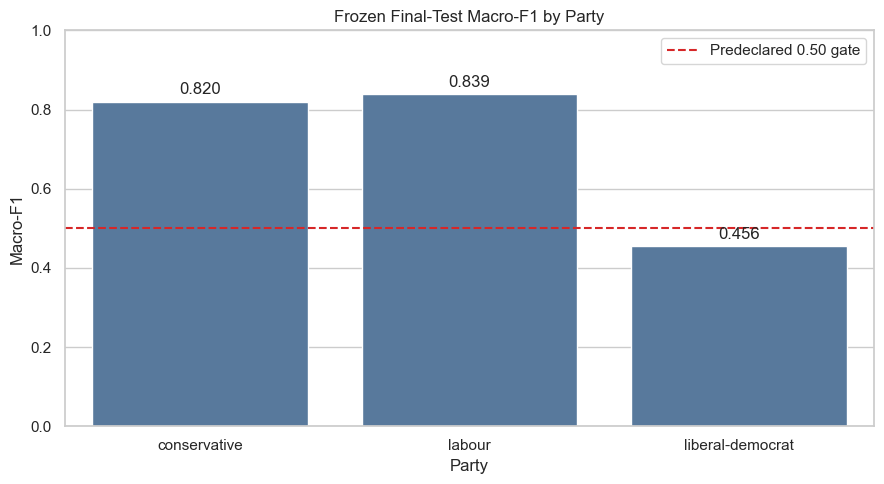

In [93]:
# 绘制三个政党的最终 Macro-F1，并保留预先设定的 0.50 参考线
primary_party_metrics = party_metrics.loc[
    party_metrics["model"].eq(PRIMARY_MODEL)
].copy()

party_order = ["conservative", "labour", "liberal-democrat"]
primary_party_metrics["party"] = pd.Categorical(
    primary_party_metrics["party"], categories=party_order, ordered=True
)
primary_party_metrics = primary_party_metrics.sort_values("party")

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=primary_party_metrics,
    x="party",
    y="macro_f1",
    color="#4C78A8",
)
ax.axhline(0.50, color="#D62728", linestyle="--", linewidth=1.5, label="Predeclared 0.50 gate")
ax.set_ylim(0, 1)
ax.set_xlabel("Party")
ax.set_ylabel("Macro-F1")
ax.set_title("Frozen Final-Test Macro-F1 by Party")
ax.legend(loc="upper right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "final_test_macro_f1_by_party.png", dpi=180, bbox_inches="tight")
plt.show()

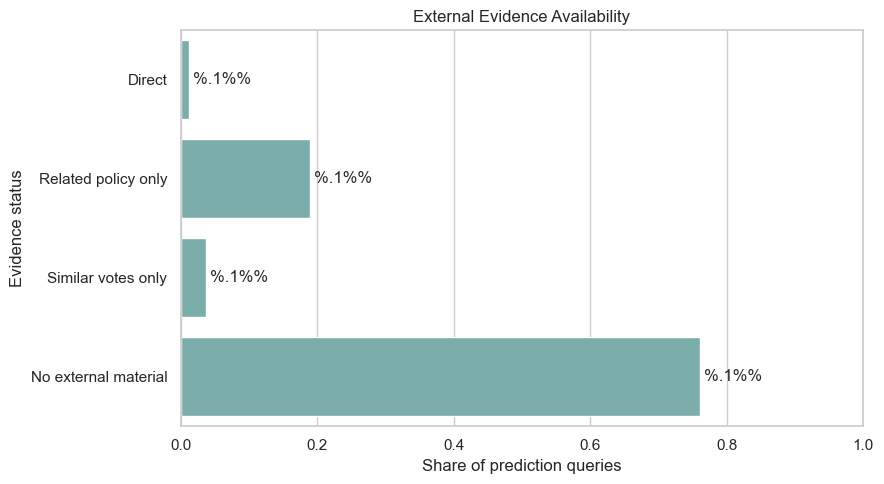

,evidence_status,queries,share,label
0,direct_evidence_available,12,0.012308,Direct
1,related_policy_material_only,185,0.189744,Related policy only
2,similar_votes_only,36,0.036923,Similar votes only
3,no_external_material,742,0.761026,No external material


In [94]:
# 将 975 条查询按最终产品证据状态画成占比图
status_order = [
    "direct_evidence_available",
    "related_policy_material_only",
    "similar_votes_only",
    "no_external_material",
]
status_labels = {
    "direct_evidence_available": "Direct",
    "related_policy_material_only": "Related policy only",
    "similar_votes_only": "Similar votes only",
    "no_external_material": "No external material",
}

evidence_coverage = (
    product["product_evidence_status_v5"]
    .value_counts()
    .reindex(status_order, fill_value=0)
    .rename_axis("evidence_status")
    .reset_index(name="queries")
)
evidence_coverage["share"] = evidence_coverage["queries"] / len(product)
evidence_coverage["label"] = evidence_coverage["evidence_status"].map(status_labels)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=evidence_coverage, x="share", y="label", color="#72B7B2")
ax.set_xlim(0, 1)
ax.set_xlabel("Share of prediction queries")
ax.set_ylabel("Evidence status")
ax.set_title("External Evidence Availability")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1%%", padding=3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "external_evidence_availability.png", dpi=180, bbox_inches="tight")
plt.show()

display(evidence_coverage)

## 10. 导出最终演示与报告文件

导出文件只包含公开预测、历史材料和汇总指标，不包含逐行 Test 真实标签。完整的 975 条预测仍然保留，即使其中大多数没有外部材料。

In [95]:
# 导出每条预测的产品摘要
product_export_columns = [
    "row_id", "division_key", "motion_date", "party", "party_role",
    "motion_title_clean", "policy_object_for_display", "motion_family",
    "policy_domain_primary", "role_probability", "recent_prior_probability",
    "support_probability", "predicted_stance", "probability_distance_band",
    "probability_formula", "top_supporting_model_drivers",
    "top_opposing_model_drivers", "product_evidence_status_v5",
    "product_evidence_message_v5", "query_id", "freeze_sha256",
]
product_export = product[product_export_columns].copy()
product_export.to_csv(OUTPUT_DIR / "final_agent_predictions_v1.csv", index=False)

# 导出经过 11E 分级的证据；历史 stance 只描述历史案例
evidence_export_columns = [
    "query_id", "row_id", "division_key", "query_date", "party",
    "query_title", "query_policy_object", "public_evidence_id_v5",
    "evidence_tier_v5", "direction_allowed_v5", "tier_reason_v5",
    "source_type", "evidence_title", "evidence_date", "evidence_party",
    "historical_party_role", "stance_label", "source_url", "evidence_text",
]
evidence[evidence_export_columns].to_csv(
    OUTPUT_DIR / "final_agent_evidence_v1.csv", index=False
)

# 导出四个代表性演示案例的结构化 JSONL
demo_jsonl_path = OUTPUT_DIR / "final_demo_cases_v1.jsonl"
with demo_jsonl_path.open("w", encoding="utf-8") as handle:
    for row_id in demo_cases["row_id"].dropna():
        handle.write(json.dumps(build_agent_output(row_id), ensure_ascii=False) + "\n")

# 导出报告指标，保留整体、政党和年份三个层级
overall_report = model_metrics.assign(metric_scope="overall", group="all")
party_report = party_metrics.assign(metric_scope="party", group=party_metrics["party"])
year_report = year_metrics.assign(metric_scope="year", group=year_metrics["motion_year"].astype(str))
report_metrics = pd.concat([overall_report, party_report, year_report], ignore_index=True, sort=False)
report_metrics.to_csv(OUTPUT_DIR / "final_report_metrics_v1.csv", index=False)

demo_cases[[
    "product_evidence_status_v5", "row_id", "division_key", "motion_date",
    "party", "motion_title_clean", "predicted_stance", "support_probability",
]].to_csv(OUTPUT_DIR / "final_demo_case_index_v1.csv", index=False)

In [96]:
# 保存一份简短运行清单，方便报告说明数据版本和产品边界
primary_overall = model_metrics.loc[model_metrics["model"].eq(PRIMARY_MODEL)].iloc[0]
completed_llm_cases = len(llm_run_results)
actual_llm_cost = (
    float(llm_run_results["actual_cost_usd"].sum())
    if not llm_run_results.empty else 0.0
)
completed_locked_cases = len(locked_eval_results)
actual_locked_cost = (
    float(locked_eval_results["actual_cost_usd"].sum())
    if not locked_eval_results.empty else 0.0
)
summary_lines = [
    "=== FINAL AGENT DEMO SUMMARY FOR REVIEW ===",
    "Notebook version: 12-final-agent-demo-v1",
    f"Frozen model: {PRIMARY_MODEL}",
    f"Freeze SHA-256 verified: {structural_gates['freeze_hash_gate']}",
    f"Public prediction rows: {len(product)}",
    f"Unique divisions: {product['division_key'].nunique()}",
    f"In-scope parties: {IN_SCOPE_PARTIES}",
    f"Final Test Macro-F1: {primary_overall['macro_f1']:.3f}",
    f"Final Test Accuracy: {primary_overall['accuracy']:.3f}",
    f"Final Test ROC-AUC: {primary_overall['roc_auc']:.3f}",
    f"Final Test Brier: {primary_overall['brier']:.3f}",
    f"Evidence rows: {len(evidence)}",
    f"Queries with Direct evidence: {(product['product_evidence_status_v5'] == 'direct_evidence_available').mean():.3f}",
    f"Queries with any external material: {(product['product_evidence_status_v5'] != 'no_external_material').mean():.3f}",
    "Prediction model changed: False",
    "Retrieval rules changed: False",
    "RAG changes probability: False",
    "Row-level Test labels read: False",
    f"LLM demo enabled: {RUN_LLM_DEMO}",
    f"New API calls this run: {new_llm_calls_this_run}",
    f"Completed cached LLM cases: {completed_llm_cases}",
    f"Actual cached LLM cost (USD): {actual_llm_cost:.6f}",
    f"LLM hard budget (USD): {HARD_BUDGET_USD:.2f}",
    f"Locked 200 evaluation enabled: {RUN_LOCKED_200_EVAL}",
    f"Locked evaluation cases completed: {completed_locked_cases}",
    f"Locked evaluation new calls this run: {locked_new_calls_this_run}",
    f"Locked evaluation actual cost (USD): {actual_locked_cost:.6f}",
    f"Locked evaluation hard budget (USD): {LOCKED_EVAL_HARD_BUDGET_USD:.2f}",
    f"Structural gates: {structural_gates}",
    f"Output directory: {OUTPUT_DIR}",
    "Next step: write the report and prepare the presentation; technical development is complete.",
    "=== END FINAL AGENT DEMO SUMMARY ===",
]

summary_text = "\n".join(summary_lines)
(OUTPUT_DIR / "final_agent_demo_summary_v1.txt").write_text(summary_text, encoding="utf-8")
print(summary_text)

=== FINAL AGENT DEMO SUMMARY FOR REVIEW ===
Notebook version: 12-final-agent-demo-v1
Frozen model: role_prior_blend_50_50
Freeze SHA-256 verified: True
Public prediction rows: 975
Unique divisions: 354
In-scope parties: ['labour', 'conservative', 'liberal-democrat']
Final Test Macro-F1: 0.801
Final Test Accuracy: 0.808
Final Test ROC-AUC: 0.869
Final Test Brier: 0.170
Evidence rows: 331
Queries with Direct evidence: 0.012
Queries with any external material: 0.239
Prediction model changed: False
Retrieval rules changed: False
RAG changes probability: False
Row-level Test labels read: False
LLM demo enabled: False
New API calls this run: 0
Completed cached LLM cases: 16
Actual cached LLM cost (USD): 0.005065
LLM hard budget (USD): 0.25
Locked 200 evaluation enabled: True
Locked evaluation cases completed: 200
Locked evaluation new calls this run: 200
Locked evaluation actual cost (USD): 0.063595
Locked evaluation hard budget (USD): 0.50
Structural gates: {'prediction_row_id_unique_gate':

## 11. 报告中应当怎样表述结论

建议使用以下谨慎结论：

> The frozen three-role model achieved an overall Macro-F1 of approximately 0.801 on the one-time final test. Performance was strong for Labour and Conservative, while Liberal Democrat performance was weaker and is reported separately. The RAG layer did not alter predictions. It supplied clearly labelled historical comparisons, related policy material and legislative context when available, and explicitly reported when reliable external material could not be found.

必须同时写入限制：

- 当前 MVP 只覆盖 Labour、Conservative 和 Liberal Democrat；
- Green 被保留在研究审计中，但不在最终预测范围内；
- Liberal Democrat 的 Macro-F1 约为 0.456，低于原定 0.50 门槛；
- Direct evidence 很少，不能声称 RAG 普遍证明了预测；
- Related policy 和 Similar votes 是辅助理解材料，不是真实标签；
- 2024 年后的政党角色映射在下一次大选或政府更替后必须更新。

至此不再新增模型实验。接下来只需要写报告、选择截图和准备演示。

## 12. 结构化输出与免费解析器修复

前面的200条评测已经锁定，因此本节不会覆盖原始结果，也不会默认发起新的API调用。本节解决两个工程问题：

1. 免费重新解析已有中文回答，兼容‘预计工党将反对’等同义表达，以及写在公式部分的概率；
2. 为未来调用定义严格JSON Schema，让程序直接读取字段，用户界面再把字段渲染成自然语言。

这样可以把‘模型/Agent回答错误’与‘中文正则没有读懂回答’分开。原始v1指标仍然保留，新结果另存为v2。

本节还增加一个可选的12条小规模党派发言测试：四种证据状态各抽3条，并尽量让Conservative、Labour和Liberal Democrat各出现一次。LLM不会重新决定支持或反对，也不会修改冻结概率；它只把模型结果、模型因素和RAG材料组织成一段明确标注为AI模拟的党派发言，再补充3个辩论要点、可能的反方质疑和回应。默认开关仍为False，因此阅读或运行免费部分不会产生API费用。

In [97]:
# 免费重评已有200条缓存：不调用API，也不修改任何原始v1文件
def parse_agent_output_fields_v2(output_text):
    # 如果未来输出已经是JSON，直接读取固定字段，不再猜中文句式
    try:
        payload = json.loads(output_text)
        if isinstance(payload, dict):
            stance = payload.get("predicted_stance")
            probability = payload.get("support_probability")
            if stance in {"support", "oppose"} and probability is not None:
                return stance, float(probability), "structured_json"
    except (json.JSONDecodeError, TypeError, ValueError):
        pass

    # 兼容旧版自然语言。方向只在‘模型计算依据’之前读取，避免误读证据内容
    prediction_section = output_text.split("模型计算依据", 1)[0]
    stance_patterns = [
        r"预测(?:结果|立场)?\s*(?:为|是|：|:)?\s*(支持|反对)",
        r"预计[^，。\n]{0,30}?(支持|反对)(?:该|这|本|《|议案|动议|提案|法案|政策|条款|修正案|$)",
        r"模型(?:预测|判断)[^，。\n]{0,20}?(支持|反对)",
    ]
    stance = None
    for pattern in stance_patterns:
        match = re.search(pattern, prediction_section, flags=re.IGNORECASE)
        if match:
            stance = "support" if match.group(1) == "支持" else "oppose"
            break
    if stance is None:
        english_match = re.search(r"\b(support|oppose)\b", prediction_section, flags=re.IGNORECASE)
        stance = english_match.group(1).lower() if english_match else None

    # 概率可以位于预测段或计算公式，但不能从外部证据段读取
    probability_section = output_text.split("外部材料", 1)[0]
    probability_patterns = [
        r"支持概率\s*(?:为|是|：|:|=)?\s*\**\s*([0-9]+(?:\.[0-9]+)?)\s*(%)?",
        r"([0-9]+(?:\.[0-9]+)?)\s*(%)?\s*(?:\\text\{)?[（(]?支持概率[）)]?",
    ]
    probability = np.nan
    for pattern in probability_patterns:
        match = re.search(pattern, probability_section, flags=re.IGNORECASE)
        if match:
            value = float(match.group(1))
            probability = value / 100 if match.group(2) or value > 1 else value
            break

    return stance, probability, "legacy_text_v2"


if locked_eval_results.empty:
    parser_v2_audit = pd.DataFrame()
    parser_v2_metrics = pd.DataFrame()
    print("没有缓存的200条回答，无法进行免费重评。")
else:
    case_lookup_v2 = locked_200_cases.set_index("row_id")
    parser_v2_rows = []

    for _, result in locked_eval_results.iterrows():
        row_id = result["row_id"]
        case = case_lookup_v2.loc[row_id]
        stance, probability, parser_type = parse_agent_output_fields_v2(result["output_text"])
        expected_stance = case["predicted_stance"]
        expected_probability = float(case["support_probability"])
        parser_v2_rows.append({
            "row_id": row_id,
            "parser_type": parser_type,
            "expected_stance": expected_stance,
            "parsed_stance_v2": stance,
            "prediction_consistent_v2": stance == expected_stance,
            "expected_support_probability": expected_probability,
            "parsed_support_probability_v2": probability,
            "probability_consistent_v2": bool(
                pd.notna(probability) and abs(probability - expected_probability) <= 0.006
            ),
        })

    parser_v2_audit = pd.DataFrame(parser_v2_rows)
    parser_v2_metric_values = {
        "rows": len(parser_v2_audit),
        "prediction_consistency_rate_v2": parser_v2_audit["prediction_consistent_v2"].mean(),
        "probability_consistency_rate_v2": parser_v2_audit["probability_consistent_v2"].mean(),
        "original_prediction_consistency_rate_v1": locked_agent_audit["prediction_consistent"].mean(),
        "original_probability_consistency_rate_v1": locked_agent_audit["probability_consistent"].mean(),
        "new_api_calls": 0,
    }
    parser_v2_metrics = pd.DataFrame([
        {"metric": key, "value": value}
        for key, value in parser_v2_metric_values.items()
    ])

    parser_v2_audit.to_csv(
        OUTPUT_DIR / "locked_200_agent_parser_v2_audit.csv", index=False
    )
    parser_v2_metrics.to_csv(
        OUTPUT_DIR / "locked_200_agent_parser_v2_metrics.csv", index=False
    )

    display(parser_v2_metrics)
    print("v1文件保持不变；v2是对同一批缓存回答的免费解析器复核。")

,metric,value
0,rows,200.00
1,prediction_consistency_rate_v2,1.00
2,probability_consistency_rate_v2,1.00
3,original_prediction_consistency_rate_v1,0.99
4,original_probability_consistency_rate_v1,0.90
5,new_api_calls,0.00


v1文件保持不变；v2是对同一批缓存回答的免费解析器复核。


In [111]:
# 为未来调用定义严格结构化输出和AI模拟党派发言。默认关闭，不会产生任何费用
RUN_STRUCTURED_OUTPUT_SMOKE_TEST = True
STRUCTURED_SMOKE_TEST_CASES = 12
STRUCTURED_SMOKE_TEST_BUDGET_USD = 0.25
STRUCTURED_SMOKE_MAX_OUTPUT_TOKENS = 4000
STRUCTURED_CACHE_PATH = OUTPUT_DIR / "structured_spokesperson_test_v4.jsonl"
STRUCTURED_FAILURE_PATH = OUTPUT_DIR / "structured_spokesperson_test_failures_v4.jsonl"

STRUCTURED_AGENT_OUTPUT_SCHEMA = {
    "type": "object",
    "properties": {
        "predicted_stance": {"type": "string", "enum": ["support", "oppose"]},
        "support_probability": {"type": "number", "minimum": 0, "maximum": 1},
        "oppose_probability": {"type": "number", "minimum": 0, "maximum": 1},
        "evidence_status": {
            "type": "string",
            "enum": [
                "direct_evidence_available",
                "similar_votes_only",
                "related_policy_material_only",
                "no_external_material",
            ],
        },
        "has_external_material": {"type": "boolean"},
        "policy_effect_interpretation": {"type": "string"},
        "model_formula": {"type": "string"},
        "prediction_analysis_markdown": {"type": "string"},
        "supporting_model_factors": {"type": "array", "items": {"type": "string"}},
        "opposing_model_factors": {"type": "array", "items": {"type": "string"}},
        "evidence_assessments": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "evidence_id": {"type": "string", "pattern": "^E[0-9]+$"},
                    "relation_to_prediction": {
                        "type": "string",
                        "enum": ["aligned", "challenging", "context"],
                    },
                    "assessment": {"type": "string"},
                },
                "required": ["evidence_id", "relation_to_prediction", "assessment"],
                "additionalProperties": False,
            },
        },
        "cited_evidence_ids": {
            "type": "array",
            "items": {"type": "string", "pattern": "^E[0-9]+$"},
        },
        "explanation_markdown": {"type": "string"},
        "simulation_label": {
            "type": "string",
            "const": "AI模拟党派发言，并非该党的真实声明",
        },
        "rhetorical_strength": {
            "type": "string",
            "enum": ["cautious", "measured", "firm"],
        },
        "simulated_spokesperson_statement_markdown": {"type": "string"},
        "debate_points": {
            "type": "array",
            "items": {"type": "string"},
            "minItems": 3,
            "maxItems": 3,
        },
        "likely_counterargument": {"type": "string"},
        "spokesperson_response": {"type": "string"},
        "statement_evidence_ids": {
            "type": "array",
            "items": {"type": "string", "pattern": "^E[0-9]+$"},
        },
        "limitations": {"type": "string"},
    },
    "required": [
        "predicted_stance",
        "support_probability",
        "oppose_probability",
        "evidence_status",
        "has_external_material",
        "policy_effect_interpretation",
        "model_formula",
        "prediction_analysis_markdown",
        "supporting_model_factors",
        "opposing_model_factors",
        "evidence_assessments",
        "cited_evidence_ids",
        "explanation_markdown",
        "simulation_label",
        "rhetorical_strength",
        "simulated_spokesperson_statement_markdown",
        "debate_points",
        "likely_counterargument",
        "spokesperson_response",
        "statement_evidence_ids",
        "limitations",
    ],
    "additionalProperties": False,
}

STRUCTURED_LLM_INSTRUCTIONS = '''
你是英国议会投票预测产品的解释和模拟辩论助手。输入中的预测已经冻结，你不能重新预测或修改概率。
predicted_stance、support_probability、oppose_probability 和 evidence_status 必须与输入完全一致。
先解释政策的直接含义：谁的税收、权利、义务或费用会改变，以及改变方向。不要把 removal of exemption 误写成免除费用；它通常表示取消原有豁免。输入不足时必须说明无法确定，不得猜测。
prediction_analysis_markdown 只解释模型为什么产生该概率，包括角色模型、近期政党先验、支持因素、反对因素和不确定性。模型概率不是政策正确性的证明，也不是政党的正式理由。
逐条填写 evidence_assessments。输入已经给出每条材料与预测的关系：aligned 表示方向一致，challenging 表示方向相反，context 表示只能作为背景。必须照抄这个关系，不能把 challenging 材料描述成支持证据。
只能引用输入包中真实存在的 evidence_id。没有外部材料时，cited_evidence_ids 必须为空数组。
Direct 只能称为历史参照；Similar、Related 和 Background 不得写成当前方向的证明。要求评估影响、发布报告或进行审查，不等于支持或反对被评估的政策本身。
凡是关于政策后果的主张，例如降低成本、增加收入或改善公平，必须由材料原文明确支持并引用对应[E编号]；否则只能写成该模拟发言人的规范性主张，不能写成已经证实的事实。
explanation_markdown 使用通俗中文，明确区分模型因素、支持材料、挑战材料和未知信息。

除分析解释外，再生成一段AI模拟党派发言：
1. simulation_label必须原样写为‘AI模拟党派发言，并非该党的真实声明’。
2. 使用正式的英国议会党派发言人口吻和第一人称复数，例如‘我们认为’，但不得冒充真实人物、不得声称这是官方声明。
3. 发言必须与predicted_stance一致。概率距离0.5不足0.10时用cautious语气；不足0.25时用measured语气；其余用firm语气。
4. 只能根据motion_title、policy_object、policy_effect_interpretation、party_role、冻结模型因素和提供的证据形成论点。不要加入资料包外的政策事实、统计数字或政党承诺。
5. Direct可以作为最接近的历史参照；Similar只能说是类似投票；Related只能说是相关政策背景；Background只能解释法案。
6. 如果没有外部材料，发言仍可围绕输入中的政策对象表达预测立场，但不得虚构依据，statement_evidence_ids必须为空。
7. 发言控制在280至450个中文字。先说明立场和政策含义，再提出两至三个理由，主动承认最强反方观点，最后说明为什么仍坚持本党立场。不要把概率数字当作辩护理由。
8. 三条debate_points每条写两至三句话，分别覆盖核心主张、现实取舍和执行或监督问题。likely_counterargument写出最有力的反方质疑，spokesperson_response用120至220个中文字正面回应。
9. 发言或辩论点使用证据时，句末必须写对应的[E编号]，statement_evidence_ids列出实际使用的编号。
不要输出Schema之外的字段。
'''.strip()


def structured_evidence_relation_map(row_id):
    # 证据方向由程序根据冻结预测和证据层级确定，不让LLM自行猜测
    packet = build_agent_output(row_id)
    predicted_stance = packet["prediction"]["predicted_stance"]
    relation_map = {}
    for item in packet["rag"]["evidence"]:
        if (
            item["tier"] == "direct_historical_evidence"
            and item["historical_stance"] in {"support", "oppose"}
        ):
            relation = (
                "aligned"
                if item["historical_stance"] == predicted_stance
                else "challenging"
            )
        else:
            relation = "context"
        relation_map[item["evidence_id"]] = relation
    return relation_map


def build_structured_llm_prompt(row_id):
    # 在原始产品包中加入冻结的证据方向，供解释层逐条使用
    packet = build_agent_output(row_id)
    relation_map = structured_evidence_relation_map(row_id)
    for item in packet["rag"]["evidence"]:
        item["relation_to_prediction"] = relation_map[item["evidence_id"]]
    packet["generation_contract"] = {
        "prediction_is_frozen": True,
        "probability_is_not_a_policy_reason": True,
        "challenging_evidence_must_be_disclosed": True,
        "context_evidence_is_not_directional_proof": True,
    }
    return json.dumps(packet, ensure_ascii=False, indent=2)


def estimate_structured_case_max_cost(prompt_text):
    # 结构化党派发言字段较多，给输出预留4000 tokens；这是上限，并不要求模型用满
    input_tokens = conservative_token_estimate(STRUCTURED_LLM_INSTRUCTIONS + prompt_text)
    return (
        input_tokens / 1_000_000 * INPUT_PRICE_PER_MILLION
        + STRUCTURED_SMOKE_MAX_OUTPUT_TOKENS / 1_000_000 * OUTPUT_PRICE_PER_MILLION
    )


def apply_frozen_agent_fields(payload, row_id):
    # 这些字段由冻结模型或确定性产品规则给出，程序直接写入，不让LLM重复判断
    case = locked_200_cases.set_index("row_id").loc[row_id]
    probability = round(float(case["support_probability"]), 4)
    evidence_status = case["product_evidence_status_v5"]
    rhetorical_strength = (
        "cautious" if abs(probability - 0.5) < 0.10
        else "measured" if abs(probability - 0.5) < 0.25
        else "firm"
    )
    payload.update({
        "predicted_stance": case["predicted_stance"],
        "support_probability": probability,
        "oppose_probability": round(1.0 - probability, 4),
        "evidence_status": evidence_status,
        "has_external_material": bool(evidence_status != "no_external_material"),
        "simulation_label": "AI模拟党派发言，并非该党的真实声明",
        "rhetorical_strength": rhetorical_strength,
    })
    frozen_relations = structured_evidence_relation_map(row_id)
    for item in payload.get("evidence_assessments", []):
        evidence_id = item.get("evidence_id")
        if evidence_id in frozen_relations:
            item["relation_to_prediction"] = frozen_relations[evidence_id]
    return payload


def validate_structured_agent_output(payload, row_id):
    # 在展示给用户前再次用程序核对冻结预测和证据编号
    case = locked_200_cases.set_index("row_id").loc[row_id]
    allowed_ids = allowed_evidence_ids(row_id)
    cited_ids = set(payload["cited_evidence_ids"])
    statement_cited_ids = set(payload["statement_evidence_ids"])
    expected_probability = round(float(case["support_probability"]), 4)
    expected_status = case["product_evidence_status_v5"]
    expected_strength = (
        "cautious" if abs(expected_probability - 0.5) < 0.10
        else "measured" if abs(expected_probability - 0.5) < 0.25
        else "firm"
    )

    frozen_relations = structured_evidence_relation_map(row_id)
    assessment_relations = {
        item["evidence_id"]: item["relation_to_prediction"]
        for item in payload.get("evidence_assessments", [])
    }
    combined_generated_text = " ".join([
        payload.get("policy_effect_interpretation", ""),
        payload.get("prediction_analysis_markdown", ""),
        payload.get("explanation_markdown", ""),
        payload.get("simulated_spokesperson_statement_markdown", ""),
        " ".join(payload.get("debate_points", [])),
        payload.get("likely_counterargument", ""),
        payload.get("spokesperson_response", ""),
    ])
    title_lower = str(case["motion_title_clean"]).lower()
    private_school_tax_case = (
        "removal of exemption" in title_lower
        and "private school fees" in title_lower
    )
    exemption_misread_phrases = [
        "减轻家庭经济负担", "降低私立学校学费", "免除私立学校学费", "取消私立学校学费"
    ]
    challenging_present = "challenging" in frozen_relations.values()
    challenging_disclosed = any(
        phrase in combined_generated_text
        for phrase in ["挑战", "相反", "反对", "冲突", "不一致"]
    )

    checks = {
        "stance_matches_frozen": payload["predicted_stance"] == case["predicted_stance"],
        "support_probability_matches_frozen": abs(payload["support_probability"] - expected_probability) <= 0.0001,
        "probabilities_sum_to_one": abs(
            payload["support_probability"] + payload["oppose_probability"] - 1
        ) <= 0.0002,
        "evidence_status_matches_frozen": payload["evidence_status"] == expected_status,
        "citations_are_allowed": cited_ids.issubset(allowed_ids),
        "statement_citations_are_allowed": statement_cited_ids.issubset(allowed_ids),
        "simulation_label_present": payload["simulation_label"] == "AI模拟党派发言，并非该党的真实声明",
        "rhetorical_strength_matches_probability": payload["rhetorical_strength"] == expected_strength,
        "statement_present": bool(payload["simulated_spokesperson_statement_markdown"].strip()),
        "statement_has_enough_depth": len(payload["simulated_spokesperson_statement_markdown"].strip()) >= 180,
        "three_debate_points_present": len(payload["debate_points"]) == 3,
        "debate_points_have_enough_depth": all(
            len(point.strip()) >= 40 for point in payload["debate_points"]
        ),
        "spokesperson_response_has_enough_depth": len(payload["spokesperson_response"].strip()) >= 80,
        "policy_effect_present": bool(payload["policy_effect_interpretation"].strip()),
        "prediction_analysis_present": bool(payload["prediction_analysis_markdown"].strip()),
        "all_evidence_assessed": set(assessment_relations) == set(frozen_relations),
        "evidence_relations_match_frozen": assessment_relations == frozen_relations,
        "challenging_evidence_disclosed": (
            challenging_disclosed if challenging_present else True
        ),
        "private_school_exemption_understood_as_tax": (
            any(term in combined_generated_text for term in ["VAT", "增值税", "税收"])
            if private_school_tax_case else True
        ),
        "private_school_exemption_not_misread_as_fee_reduction": (
            not any(phrase in combined_generated_text for phrase in exemption_misread_phrases)
            if private_school_tax_case else True
        ),
        "external_material_flag_correct": payload["has_external_material"] == (expected_status != "no_external_material"),
        "no_evidence_has_no_citations": (
            not cited_ids and not statement_cited_ids
            if expected_status == "no_external_material" else True
        ),
        "evidence_case_has_citation": (
            bool(cited_ids) if expected_status != "no_external_material" else True
        ),
    }
    return checks


def render_structured_agent_output(payload, row_id):
    # 标题和政策对象直接取冻结输入，避免LLM改写或遗漏讨论对象
    case = locked_200_cases.set_index("row_id").loc[row_id]
    stance_cn = "支持" if payload["predicted_stance"] == "support" else "反对"
    relation_cn = {"aligned": "与预测一致", "challenging": "挑战预测", "context": "仅作背景"}
    evidence_lines = [
        f"- {item['evidence_id']}（{relation_cn[item['relation_to_prediction']]}）：{item['assessment']}"
        for item in payload.get("evidence_assessments", [])
    ] or ["- 当前没有可用的外部材料。"]
    return "\n".join([
        "### 讨论对象",
        f"政党：{case['party']}",
        f"法案或动议标题：{case['motion_title_clean']}",
        f"政策对象：{case['policy_object_for_display']}",
        "",
        "### 政策实际含义",
        payload["policy_effect_interpretation"],
        "",
        "### 预测结果",
        f"预测结果为{stance_cn}。支持概率为 {payload['support_probability']:.2%}，"
        f"反对概率为 {payload['oppose_probability']:.2%}。",
        "",
        "### 模型计算依据",
        payload["model_formula"],
        "",
        "### 为什么模型会给出这个结果",
        payload["prediction_analysis_markdown"],
        "",
        "### 检索材料与预测的关系",
        *evidence_lines,
        "",
        "### 分析解释",
        payload["explanation_markdown"],
        "",
        f"### {payload['simulation_label']}",
        f"语气强度：`{payload['rhetorical_strength']}`",
        "",
        payload["simulated_spokesperson_statement_markdown"],
        "",
        "### Debate要点",
        *[f"- {point}" for point in payload["debate_points"]],
        "",
        "### 可能的反方质疑",
        payload["likely_counterargument"],
        "",
        "### 发言人回应",
        payload["spokesperson_response"],
        "",
        "### 限制",
        payload["limitations"],
    ])

print("结构化党派发言Schema已准备完成。默认只测试12条，开关为False时不会调用API。")

结构化党派发言Schema已准备完成。默认只测试12条，开关为False时不会调用API。


In [112]:
# 可选：只用12条案例验证党派发言与结构化输出。默认关闭，且有0.25美元硬预算
structured_smoke_records = load_llm_cache(STRUCTURED_CACHE_PATH)
structured_failure_records = []
if STRUCTURED_FAILURE_PATH.exists():
    with STRUCTURED_FAILURE_PATH.open(encoding="utf-8") as handle:
        for line in handle:
            if line.strip():
                structured_failure_records.append(json.loads(line))
structured_cost_so_far = sum(
    float(record.get("actual_cost_usd", 0.0))
    for record in structured_smoke_records.values()
) + sum(
    float(record.get("actual_cost_usd", 0.0))
    for record in structured_failure_records
)

if RUN_STRUCTURED_OUTPUT_SMOKE_TEST:
    import os
    from getpass import getpass
    from openai import OpenAI

    if "client" not in globals():
        structured_api_key = os.environ.get("OPENAI_API_KEY", "").strip()
        if not structured_api_key:
            structured_api_key = getpass("请粘贴OpenAI API key：").strip()
        if not structured_api_key:
            raise EnvironmentError("没有提供API key，未发生任何调用。")
        client = OpenAI(api_key=structured_api_key)

    # 固定覆盖四种证据状态，并尽量覆盖三个政党；不是简单取前12行
    smoke_quotas = {
        "direct_evidence_available": 3,
        "similar_votes_only": 3,
        "related_policy_material_only": 3,
        "no_external_material": 3,
    }
    smoke_parts = []
    for evidence_status, quota in smoke_quotas.items():
        candidates = locked_200_cases.loc[
            locked_200_cases["product_evidence_status_v5"].eq(evidence_status)
        ].copy()
        candidates = candidates.sort_values(["motion_date", "party", "row_id"])
        party_first = candidates.groupby("party", group_keys=False).head(1)
        selected_ids = set(party_first.head(quota)["row_id"])
        remainder = candidates.loc[~candidates["row_id"].isin(selected_ids)]
        selected = pd.concat([party_first.head(quota), remainder.head(max(0, quota - len(selected_ids)))])
        smoke_parts.append(selected.head(quota))
    smoke_cases = pd.concat(smoke_parts, ignore_index=True).head(STRUCTURED_SMOKE_TEST_CASES)
    completed_smoke_cases = int(smoke_cases["row_id"].isin(structured_smoke_records).sum())
    print(
        f"结构化测试进度：已缓存 {completed_smoke_cases}/{len(smoke_cases)} 条；"
        f"本次最多补跑 {len(smoke_cases) - completed_smoke_cases} 条。"
    )
    smoke_cases[[
        "row_id", "party", "motion_date", "motion_title_clean",
        "predicted_stance", "support_probability", "product_evidence_status_v5",
    ]].to_csv(OUTPUT_DIR / "structured_spokesperson_test_cases_v4.csv", index=False)
    for _, case in smoke_cases.iterrows():
        row_id = case["row_id"]
        if row_id in structured_smoke_records:
            continue
        prompt_text = build_structured_llm_prompt(row_id)
        estimated_next_cost = estimate_structured_case_max_cost(prompt_text)
        if structured_cost_so_far + estimated_next_cost > STRUCTURED_SMOKE_TEST_BUDGET_USD:
            print("结构化党派发言测试已触发0.25美元预算保护。")
            break

        response = client.responses.create(
            model=LLM_MODEL,
            instructions=STRUCTURED_LLM_INSTRUCTIONS,
            input=prompt_text,
            text={
                "format": {
                    "type": "json_schema",
                    "name": "party_stance_explanation_v4",
                    "strict": True,
                    "schema": STRUCTURED_AGENT_OUTPUT_SCHEMA,
                }
            },
            max_output_tokens=STRUCTURED_SMOKE_MAX_OUTPUT_TOKENS,
            temperature=0,
            store=False,
        )

        input_tokens = usage_value(response.usage, "input_tokens")
        output_tokens = usage_value(response.usage, "output_tokens")
        actual_cost = calculate_actual_cost(input_tokens, output_tokens)
        structured_cost_so_far += actual_cost

        raw_status = getattr(response, "status", "unknown")
        response_status = str(getattr(raw_status, "value", raw_status))
        incomplete_details = getattr(response, "incomplete_details", None)
        incomplete_reason = (
            incomplete_details.get("reason")
            if isinstance(incomplete_details, dict)
            else getattr(incomplete_details, "reason", None)
        )
        raw_output = response.output_text or ""
        if response_status != "completed":
            failure_record = {
                "row_id": row_id,
                "response_status": response_status,
                "incomplete_reason": incomplete_reason,
                "raw_output": raw_output,
                "input_tokens": input_tokens,
                "output_tokens": output_tokens,
                "actual_cost_usd": actual_cost,
            }
            with STRUCTURED_FAILURE_PATH.open("a", encoding="utf-8") as handle:
                handle.write(json.dumps(failure_record, ensure_ascii=False) + "\n")
            print(f"Incomplete response: {row_id} | {incomplete_reason}; 已记录并继续。")
            continue

        try:
            payload = json.loads(raw_output)
        except json.JSONDecodeError as exc:
            failure_record = {
                "row_id": row_id,
                "response_status": response_status,
                "incomplete_reason": "json_decode_error",
                "json_error": str(exc),
                "raw_output": raw_output,
                "input_tokens": input_tokens,
                "output_tokens": output_tokens,
                "actual_cost_usd": actual_cost,
            }
            with STRUCTURED_FAILURE_PATH.open("a", encoding="utf-8") as handle:
                handle.write(json.dumps(failure_record, ensure_ascii=False) + "\n")
            print(f"JSON parse warning: {row_id}; 已记录并继续。")
            continue

        payload = apply_frozen_agent_fields(payload, row_id)
        validation_checks = validate_structured_agent_output(payload, row_id)
        validation_passed = all(validation_checks.values())
        if not validation_passed:
            failed_checks = [name for name, passed in validation_checks.items() if not passed]
            print(f"Validation warning: {row_id} | {failed_checks}")

        record = {
            "row_id": row_id,
            "payload": payload,
            "rendered_output": (
                render_structured_agent_output(payload, row_id)
                if validation_passed
                else "该案例未通过发布校验，仅保留作测试记录。"
            ),
            "validation_checks": validation_checks,
            "input_tokens": input_tokens,
            "output_tokens": output_tokens,
            "actual_cost_usd": actual_cost,
        }
        with STRUCTURED_CACHE_PATH.open("a", encoding="utf-8") as handle:
            handle.write(json.dumps(record, ensure_ascii=False) + "\n")
        structured_smoke_records[row_id] = record
        print(f"Structured output completed: {row_id} | cost ${structured_cost_so_far:.6f}")

    structured_case_lookup = locked_200_cases.set_index("row_id")
    structured_smoke_table = pd.DataFrame([
        {
            "row_id": row_id,
            "party": structured_case_lookup.loc[row_id, "party"],
            "motion_title": structured_case_lookup.loc[row_id, "motion_title_clean"],
            "policy_object": structured_case_lookup.loc[row_id, "policy_object_for_display"],
            "predicted_stance": record["payload"]["predicted_stance"],
            "support_probability": record["payload"]["support_probability"],
            "evidence_status": record["payload"]["evidence_status"],
            "policy_effect_interpretation": record["payload"]["policy_effect_interpretation"],
            "prediction_analysis": record["payload"]["prediction_analysis_markdown"],
            "evidence_assessments": " | ".join(
                f"{item['evidence_id']}:{item['relation_to_prediction']}:{item['assessment']}"
                for item in record["payload"]["evidence_assessments"]
            ),
            "rhetorical_strength": record["payload"]["rhetorical_strength"],
            "simulated_spokesperson_statement": record["payload"]["simulated_spokesperson_statement_markdown"],
            "debate_points": " | ".join(record["payload"]["debate_points"]),
            "likely_counterargument": record["payload"]["likely_counterargument"],
            "spokesperson_response": record["payload"]["spokesperson_response"],
            "statement_evidence_ids": " | ".join(record["payload"]["statement_evidence_ids"]),
            "rendered_output": render_structured_agent_output(record["payload"], row_id),
            "actual_cost_usd": record["actual_cost_usd"],
            "validation_failures": " | ".join(
                name for name, passed in record["validation_checks"].items() if not passed
            ),
            "all_structural_and_semantic_checks_passed": all(record["validation_checks"].values()),
        }
        for row_id, record in structured_smoke_records.items()
    ])
    structured_smoke_table.to_csv(
        OUTPUT_DIR / "structured_spokesperson_test_results_v4.csv", index=False
    )
    display(structured_smoke_table)
else:
    print("RUN_STRUCTURED_OUTPUT_SMOKE_TEST=False：没有发生新的API调用。")

结构化测试进度：已缓存 0/12 条；本次最多补跑 12 条。
Validation warning: pw-2025-03-03-111-commons__labour | ['private_school_exemption_understood_as_tax']
Structured output completed: pw-2025-03-03-111-commons__labour | cost $0.000903
Structured output completed: pw-2025-03-03-111-commons__liberal-democrat | cost $0.001771
Validation warning: pw-2025-03-12-123-commons__conservative | ['statement_has_enough_depth']
Structured output completed: pw-2025-03-12-123-commons__conservative | cost $0.002569
Validation warning: pw-2025-05-12-192-commons__conservative | ['debate_points_have_enough_depth']
Structured output completed: pw-2025-05-12-192-commons__conservative | cost $0.003395
Validation warning: pw-2025-05-12-192-commons__labour | ['debate_points_have_enough_depth']
Structured output completed: pw-2025-05-12-192-commons__labour | cost $0.004222
Validation warning: pw-2025-06-10-222-commons__liberal-democrat | ['statement_has_enough_depth']
Structured output completed: pw-2025-06-10-222-commons__liberal

,row_id,party,motion_title,policy_object,predicted_stance,support_probability,evidence_status,policy_effect_interpretation,prediction_analysis,evidence_assessments,rhetorical_strength,simulated_spokesperson_statement,debate_points,likely_counterargument,spokesperson_response,statement_evidence_ids,rendered_output,actual_cost_usd,validation_failures,all_structural_and_semantic_checks_passed
0,pw-2025-03-03-111-commons__labour,labour,Clause 47 - Removal of exemption for private school fees,Clause 47 - Removal of exemption for private school fees,support,0.5205,direct_evidence_available,取消私立学校费用的豁免将导致私立学校的费用增加，影响家庭的经济负担，同时可能使得更多家庭选择公立学校。,模型预测支持的概率为52.05%，主要基于以下因素：首先，作为执政党，工党在类似议案中有较强的支持倾向（+0.280 log-odds）；其次，近期的投票记录显示工党在此类议案中也倾向于支持（+0.637 log-odds）。然而，作为执政党，工党在某些情况下可能会面临反对压力（-0.533 log-odds）...,E1:aligned:历史投票显示工党在此议案中支持，符合当前预测方向。 | E2:context:该材料提供了政策背景，但并不直接支持或反对当前议案。,cautious,我们认为，取消私立学校费用的豁免是实现教育公平的重要一步。这一政策将使得私立学校的费用增加，从而促使更多家庭考虑公立学校的选择，减轻教育资源的不平等。我们承认，反对者可能会担心这一政策会增加家庭的经济负担，尤其是在经济压力较大的情况下。然而，我们相信，通过合理的财政政策和支持措施，可以有效缓解这一问题。我们仍然...,首先，取消私立学校费用的豁免将有助于减少教育资源的不平等，使得更多家庭能够平等地享受教育机会。 | 其次，虽然反对者担心这一政策会增加家庭的经济负担，但我们相信，政府可以通过其他方式提供支持，确保所有家庭都能负担得起教育费用。 | 最后，实施这一政策后，政府需要加强对教育资源的监管，确保资金的合理分配和使用，以...,反对者可能会质疑这一政策会导致家庭经济负担加重，尤其是在经济不景气的情况下。,我们理解反对者的担忧，尤其是在当前经济形势下，家庭的财务压力确实是一个重要问题。然而，我们相信，教育公平是社会发展的基石，必须优先考虑。通过取消私立学校费用的豁免，我们不仅能够促进教育资源的公平分配，还能激励政府在公立教育上投入更多资源，确保每个孩子都能接受优质教育。我们将继续关注家庭的经济状况，并采取必要的措...,E1 | E2,### 讨论对象\n政党：labour\n法案或动议标题：Clause 47 - Removal of exemption for private school fees\n政策对象：Clause 47 - Removal of exemption for private school fees\n\n### ...,0.000903,private_school_exemption_understood_as_tax,False
1,pw-2025-03-03-111-commons__liberal-democrat,liberal-democrat,Clause 47 - Removal of exemption for private school fees,Clause 47 - Removal of exemption for private school fees,support,0.7040,direct_evidence_available,取消私立学校费用的豁免将导致私立学校的费用增加，影响家庭的经济负担。,模型预测支持的概率为70.4%，主要基于党派角色和近期投票的影响。支持因素包括：作为小型反对党，通常会支持增加公共收入的措施；而反对因素则是该动议为上议院修正案，可能影响其支持度。,E1:challenging:历史投票显示该党曾反对类似动议，可能影响当前支持立场。 | E2:context:相关政策材料提供了背景信息，但不直接支持当前动议的方向。,measured,我们支持取消私立学校费用的豁免。这一政策将有助于增加公共财政收入，确保教育资源的公平分配。首先，私立学校的费用豁免使得富裕家庭享有不公平的税收优势，而取消这一豁免将有助于缩小教育资源的差距。其次，增加的税收可以用于改善公立学校的设施和教学质量，造福更多学生。尽管有人担心这一政策可能增加家庭的经济负担，但我们认为...,取消私立学校费用的豁免将有助于实现教育资源的公平分配，确保每个孩子都能接受优质教育。 | 虽然这一政策可能会增加部分家庭的经济负担，但我们必须优先考虑教育公平，确保公共资金用于最需要的地方。 | 我们需要建立有效的监督机制，确保增加的税收能够真正用于改善公立学校的教育质量，而不是被浪费。,反对者可能会质疑这一政策会加重家庭的经济负担，尤其是中产阶级家庭。,我们理解反对者的担忧，确实，取消私立学校费用的豁免可能会对一些家庭造成经济压力。然而，我们认为，教育公平是社会发展的核心。通过合理的政策设计，我们可以确保低收入家庭得到必要的支持，减轻他们的负担。同时，增加的税收将用于改善公立学校的教育质量，最终惠及更多学生。我们必须勇于采取措施，推动教育公平，而不是因短期的经...,E1 | E2,### 讨论对象\n政党：liberal-democrat\n法案或动议标题：Clause 47 - Removal of exemption for private school fees\n政策对象：Clause 47 - Removal of exemption for private school fe...,0.000868,,True
2,pw-2025-03-12-123-commons__conservative,conservative,Third Reading: Employment Rights Bill,Employment Rights Bill,oppose,0.2961,direct_evidence_available,该法案可能会改变雇主与雇员之间的权利和义务，增加雇主的合规成本，影响雇佣决策。,模型预测显示保守党在此法案上可能会反对，主要基于其在类似法案上的历史投票记录。支持因素包括该法案的时间和党派角色的互动，而反对因素则是法案类型和内容的特性。,E1:aligned:该历史投票显示保守党在类似法案上持反对态度，支持当前预测。,measured,我们反对《就业权利法案》。该法案将改变雇主与雇员之间的权利和义务，可能导致雇主面临更高的合规成本，从而影响雇佣决策。我们认为，增加的法规负担将对企业的灵活性和竞争力产生负面影响。虽然支持者可能认为该法案有助于保护员工权益，但我们担心这将导致雇主在招聘和留用员工方面的犹豫。我们在2024年10月的投票中已明确表示...,首先，该法案将增加雇主的合规成本，可能导致企业在招聘时更加谨慎，从而影响就业机会。 | 其次，虽然法案旨在保护员工权益，但过多的法规可能会抑制企业的灵活性，影响其在市场中的竞争力。 | 最后，实施和监督这些新规定将面临挑战，可能导致法律执行不力，最终损害员工的利益。,反对者可能会认为该法案是保护员工权益的必要措施，能够改善工作条件和保障就业安全。,我们理解保护员工权益的重要性，但我们认为，过度的法规会导致雇主在招聘和留用员工方面的犹豫，最终可能适得其反。我们需要找到一个平衡点，既能保护员工权益，又不损害企业的灵活性和竞争力。我们在历史投票中已明确反对这一法案，基于对经济和就业市场的深刻理解。,E1,### 讨论对象\n政党：conservative\n法案或动议标题：Third Reading: Employment Rights Bill\n政策对象：Employment Rights Bill\n\n### 政策实际含义\n该法案可能会改变雇主与雇员之间的权利和义务，增加雇主的合规成本，影响雇佣决策。...,0.000798,statement_has_enough_depth,False
3,pw-2025-05-12-192-commons__conservative,conservative,"New Clause 14: Border Security, Asylum and Immigration Bill",Borders legislation: Human Rights Act _,support,0.5087,similar_votes_only,该政策将影响边境安全和移民法，可能会改变人权法案的适用性，影响移民的权利和义务。,模型预测出该政策的支持概率为50.87%，主要基